In [1]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from bluemath_tk.datamining.pca import PCA
from bluemath_tk.core.operations import spatial_gradient
from bluemath_tk.predictor.xwt import get_dynamic_estela_predictor

#### Load Data (Cyclone Model)

In [4]:
#### Load Data ###
data_slp = xr.open_dataset('inputs/global_mslp_1day_1degree.nc')
data_slp["mslp"] = data_slp["mslp"]  # Convert from Pa to hPa
data_slp["mslp_gradient"] = spatial_gradient(data_slp["mslp"])
data_slp_org = data_slp.copy()

In [5]:
data_slp_org 

<xarray.Dataset> Size: 16GB
Dimensions:        (time: 30642, latitude: 181, longitude: 360)
Coordinates:
  * time           (time) datetime64[ns] 245kB 1940-01-01 ... 2023-11-22
  * latitude       (latitude) float32 724B 89.62 88.62 87.62 ... -89.38 -90.0
  * longitude      (longitude) float32 1kB 0.375 1.375 2.375 ... 358.4 359.4
Data variables:
    mslp           (time, latitude, longitude) float32 8GB 1.041e+05 ... 9.99...
    mslp_gradient  (time, latitude, longitude) float32 8GB 0.0 0.0 ... 0.0 0.0

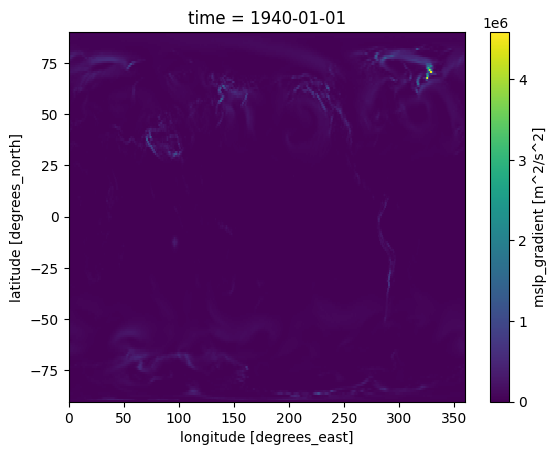

In [6]:
data_slp.isel(time=0).mslp_gradient.plot()

## ESTELA

In [8]:
estela = xr.open_dataset("inputs/estela_sea.nc", decode_times=False)
data_slp = get_dynamic_estela_predictor(data=data_slp, estela=estela)

In [9]:
data_slp = data_slp.isel(time=slice(30,None))
data_slp

<xarray.Dataset> Size: 16GB
Dimensions:        (time: 30612, latitude: 181, longitude: 360)
Coordinates:
  * time           (time) datetime64[ns] 245kB 1940-01-31 ... 2023-11-22
  * latitude       (latitude) float32 724B 89.62 88.62 87.62 ... -89.38 -90.0
  * longitude      (longitude) float32 1kB 0.375 1.375 2.375 ... 358.4 359.4
Data variables:
    mslp           (time, latitude, longitude) float32 8GB nan nan ... nan nan
    mslp_gradient  (time, latitude, longitude) float32 8GB nan nan ... nan nan

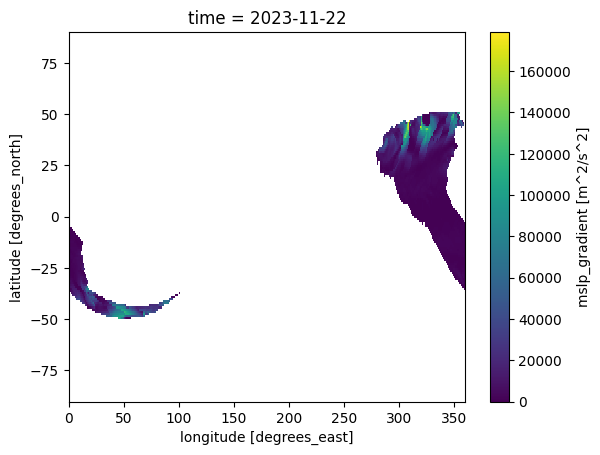

In [10]:
data_slp.isel(time=-1).mslp_gradient.plot()

#### Principal Component Analysis - MSLP

In [11]:
pca_mslp = PCA(n_components=0.95)


        -------------------------------------------------------------------
        | Initializing PCA reduction model with the following parameters:
        |    - n_components: 0.95
        |    - is_incremental: False
        | For more information, please refer to the documentation.
        -------------------------------------------------------------------
        


In [12]:
pca_mslp.fit_transform(data=data_slp, vars_to_stack=["mslp","mslp_gradient"], coords_to_stack=["latitude", "longitude"], pca_dim_for_rows="time")

2026-07-07 10:57:14,419 - PCA - WARNING - Using 4488 out of 65160 available variablesIf this is originated by using few times, please check 'nan_threshold_to_drop' parameter in fit method
2026-07-07 10:57:16,692 - PCA - WARNING - Using 4488 out of 65160 available variablesIf this is originated by using few times, please check 'nan_threshold_to_drop' parameter in fit method


<xarray.Dataset> Size: 52MB
Dimensions:      (time: 30612, n_component: 422)
Coordinates:
  * time         (time) datetime64[ns] 245kB 1940-01-31 ... 2023-11-22
  * n_component  (n_component) int64 3kB 0 1 2 3 4 5 ... 416 417 418 419 420 421
Data variables:
    PCs          (time, n_component) float32 52MB -58.04 3.83 ... 0.6512 0.2074
    stds         (n_component) float32 2kB 36.85 28.32 20.2 ... 1.125 1.123

In [13]:
(pca_mslp.is_fitted == True)

True

In [14]:
pca_mslp.save_model("/nfs/home/geocean/montanoj/New_data_Shoreshop/outputs/PCA/pca_mslp_model.pkl")
pca_mslp.pcs_df.to_csv('/nfs/home/geocean/montanoj/New_data_Shoreshop/outputs/PCA/pcs_mslp_df.csv')
pca_mslp.pcs.to_netcdf('/nfs/home/geocean/montanoj/New_data_Shoreshop/outputs/PCA/pcs_mslp_ds.nc')
pca_mslp.eofs.to_netcdf('/nfs/home/geocean/montanoj/New_data_Shoreshop/outputs/PCA/eofs_mslp.nc')

2026-07-07 10:59:49,636 - PCA - WARNING - Attribute pcs is an xarray Dataset / Dataarray and will be pickled!


#### Plot PCS

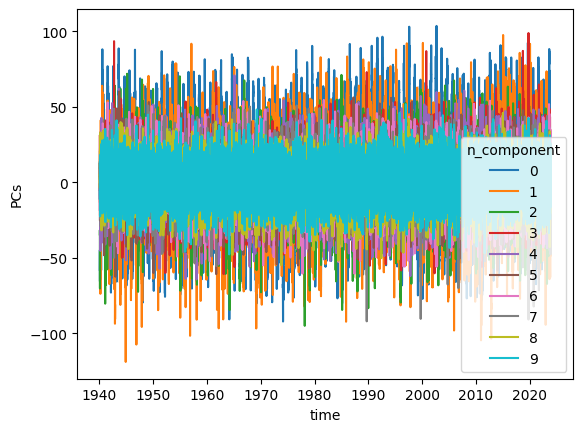

In [15]:
pca_mslp.plot_pcs(num_pcs=10)

In [16]:
df = pca_mslp.pcs_df

import pandas as pd
import numpy as np
import statsmodels.api as sm

results = []

# numeric time variable
t = np.arange(len(df))

for col in df.columns:
    y = df[col].values
    X = sm.add_constant(t)
    model = sm.OLS(y, X).fit()

    results.append({
        "column": col,
        "slope": model.params[1],
        "p_value": model.pvalues[1],
        "r_squared": model.rsquared
    })

trend_results = pd.DataFrame(results)
trend_results


,column,slope,p_value,r_squared
0,PC1,1.956136e-04,2.183220e-16,0.002200
1,PC2,2.554332e-04,2.468255e-44,0.006353
2,PC3,7.410705e-06,5.705844e-01,0.000011
3,PC4,2.177447e-04,3.350731e-96,0.014051
4,PC5,1.841089e-04,1.033720e-71,0.010422
...,...,...,...,...
417,PC418,1.372693e-07,8.516061e-01,0.000001
418,PC419,-4.696142e-07,5.215870e-01,0.000013
419,PC420,2.452486e-06,8.026989e-04,0.000367
420,PC421,-2.313931e-07,7.505216e-01,0.000003


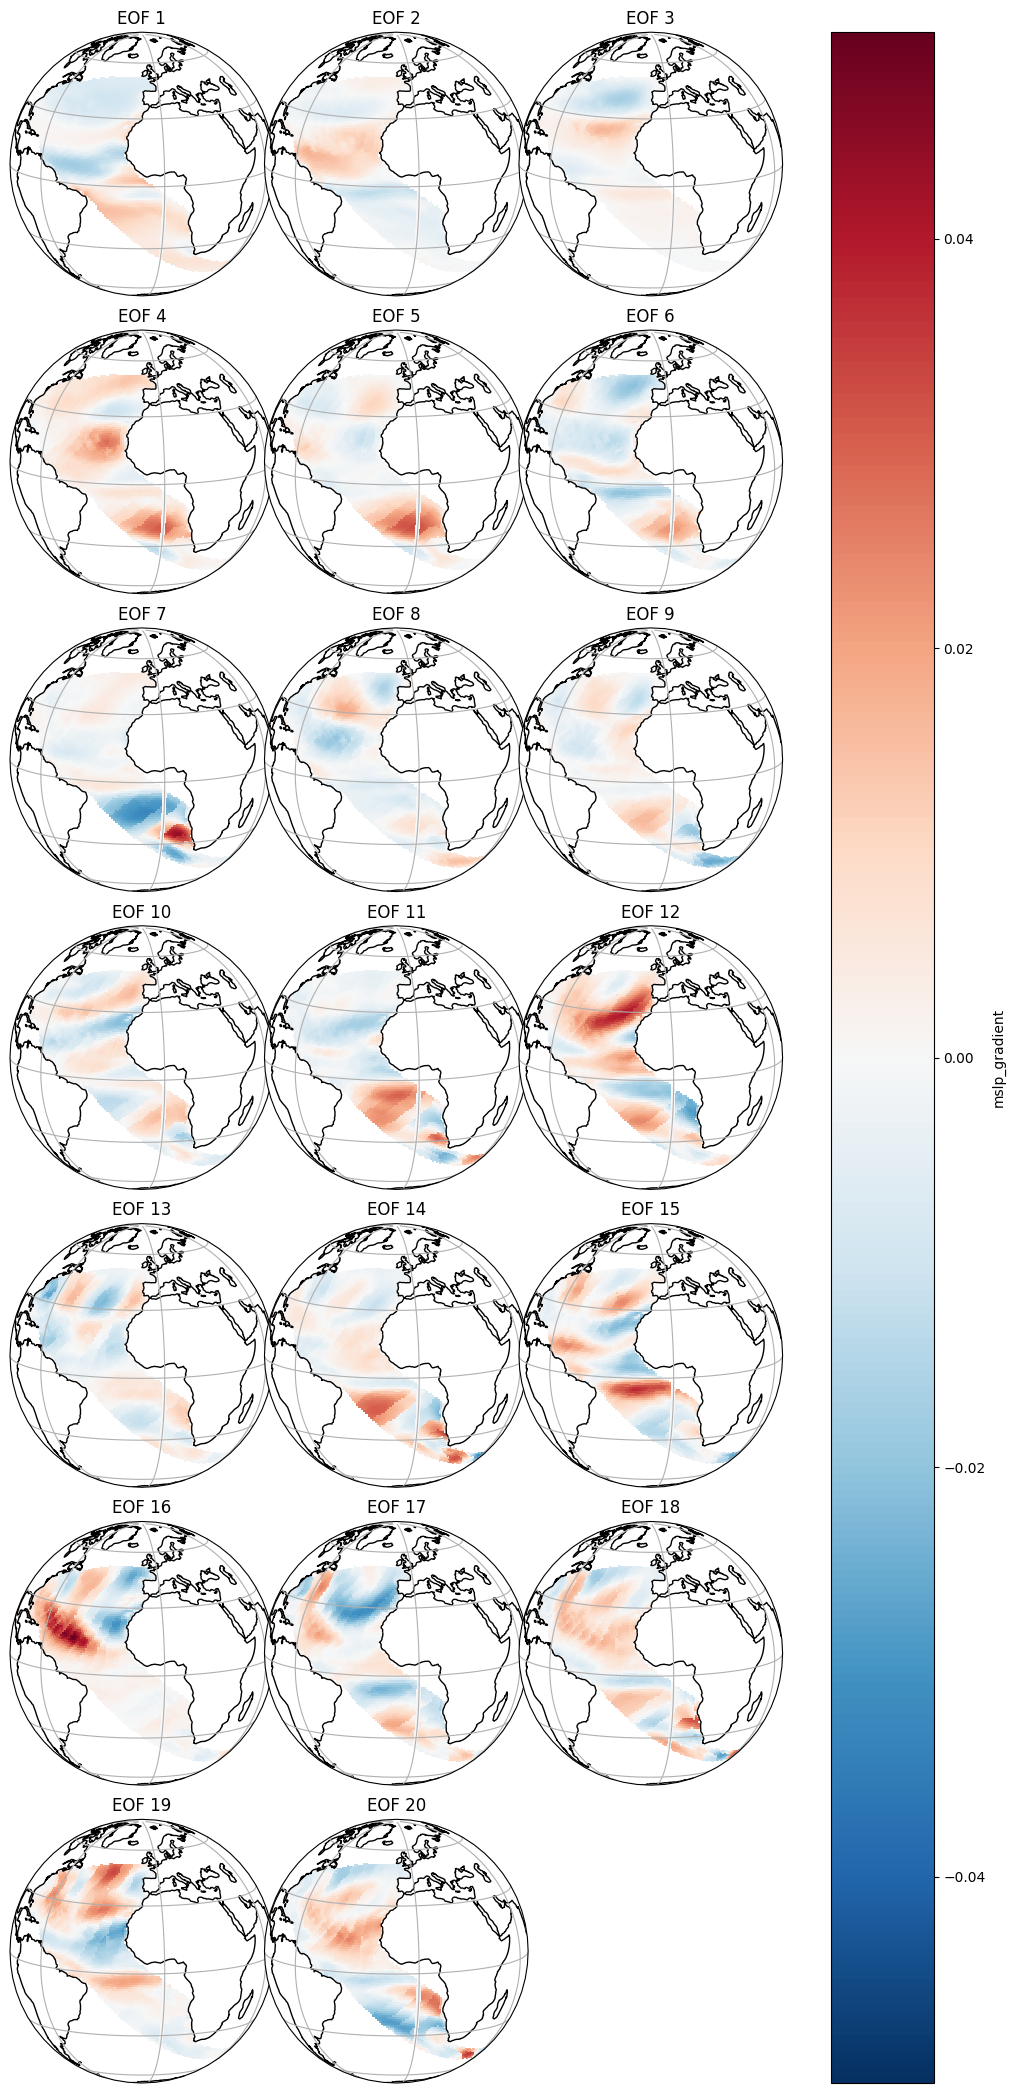

In [17]:
pca_mslp.plot_eofs(vars_to_plot=['mslp_gradient'],num_eofs=20, map_center=(-10, 10))


In [18]:
pcs_df = pca_mslp.pcs_df
pcs_df.index = pd.to_datetime(pcs_df.index, format='mixed')

In [20]:
waves_df = pd.read_csv('/nfs/home/geocean/montanoj/New_data_Shoreshop/outputs/KMA/nearest_centroids_df_kma_sorted.csv', index_col=0, parse_dates=True)
waves_df.index = pd.to_datetime(waves_df.index, format='mixed')

In [21]:
start_dates = max(pcs_df.index.min(), waves_df.index.min())
end_dates = min(pcs_df.index.max(), waves_df.index.max())
pcs_df = pcs_df.loc[start_dates:end_dates]
waves_df = waves_df.loc[start_dates:end_dates]
waves_df


,dp0g1,dp0g2,dp0g3,dp0g4,dp1g1,dp1g2,dp1g3,dp1g4,hs0g1,hs0g2,...,wd0g1,wd0g2,wd0g3,wd0g4,ws0g1,ws0g2,ws0g3,ws0g4,kma_bmus,kma_bmus_sorted
1980-01-01,28.782043,35.703796,39.281310,39.850890,89.152954,145.926850,189.337460,179.271970,0.382740,0.940579,...,292.409572,304.735141,11.158457,20.563651,7.553808,4.869604,10.235694,10.320283,119,89
1980-01-02,318.195160,327.712280,9.877014,26.591430,214.929410,66.906340,103.681885,107.983340,1.050795,1.177428,...,306.765543,303.416628,327.942107,334.855340,10.016481,7.349875,11.601874,10.773316,79,80
1980-01-03,354.997560,331.300230,316.541230,311.173770,72.304110,64.333496,50.085205,53.043365,0.283832,0.267952,...,357.441789,357.291148,334.044467,349.017279,3.773770,4.107564,5.699790,5.420217,76,33
1980-01-04,41.288820,52.395294,89.286470,45.602356,61.830690,72.263000,56.727110,62.108154,0.145059,0.202360,...,88.889658,67.234282,106.936122,53.808682,4.027967,4.898098,6.704189,6.837090,77,70
1980-01-05,302.820700,302.940500,309.122650,45.685272,177.106380,174.610840,54.831420,160.388850,1.256407,1.236957,...,310.266064,312.039953,303.962826,330.388824,10.537236,8.628696,11.271146,10.397302,47,16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-11-18,357.108520,39.359100,348.023320,341.370880,140.253420,140.336300,158.202030,155.510680,0.027800,0.108290,...,22.928495,5.375379,20.855045,6.413815,8.727995,4.604550,8.252207,5.218633,113,81
2023-11-19,74.404270,62.520570,18.869354,10.800995,122.369230,119.702120,126.582490,126.635680,1.501517,1.598826,...,43.527083,42.248412,19.511140,12.730200,8.618773,6.367436,9.782240,8.976334,109,75
2023-11-20,64.489380,63.182740,32.470123,30.923737,107.767240,113.497650,113.105530,114.981750,0.808519,1.141583,...,64.847804,52.436675,56.364010,28.609255,6.441152,6.585081,7.399501,7.477255,109,75
2023-11-21,115.983340,123.777710,88.835690,67.987946,48.719696,83.386720,73.467224,91.405270,2.269762,2.047011,...,139.203379,135.983564,121.538567,103.371000,11.575684,8.148464,10.589594,8.224907,130,38


In [24]:
waves_df['energy'] = waves_df['hs1g4']**2 * waves_df['tp1g4']

from sklearn.linear_model import LinearRegression
X = pcs_df.values
y = waves_df['energy'].values

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

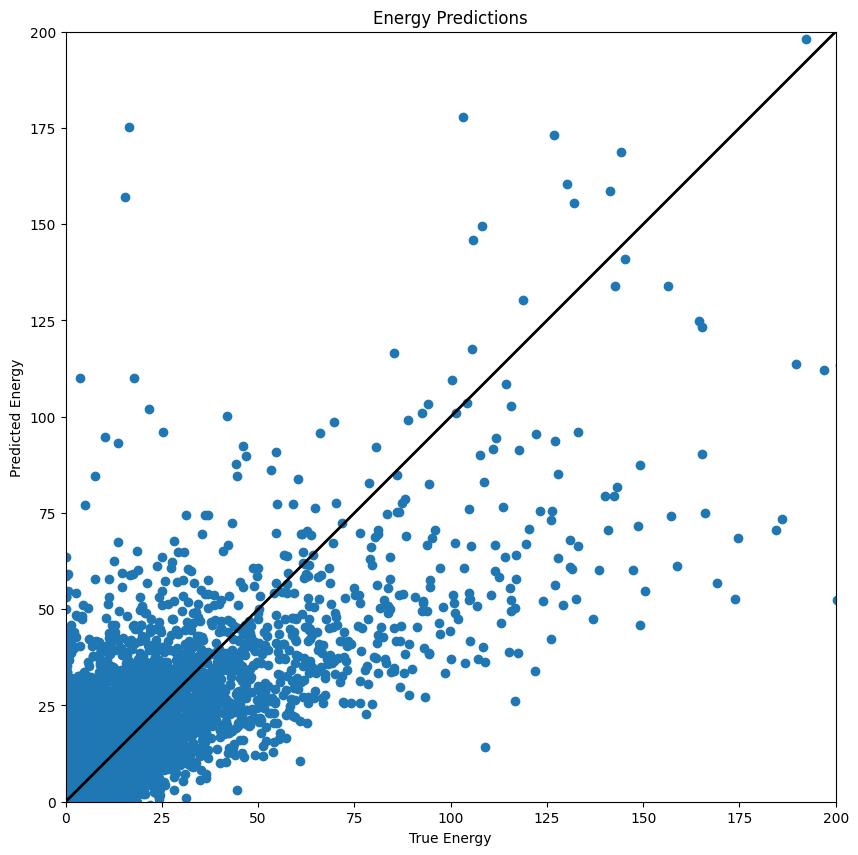

In [25]:
fig, ax = plt.subplots(1,1, figsize=(10,10))
ax.plot([0,1500],[0,1500], color='black', lw=2)
ax.scatter(y,y_pred)
ax.set_aspect('equal')
ax.set_xlabel('True Energy')
ax.set_ylabel('Predicted Energy')
ax.set_title('Energy Predictions')
ax.set_ylim(0,200)
ax.set_xlim(0,200)
plt.show()


## LONG TERM PCs MSLP (20CR)

In [26]:
mslp_20cr = xr.open_dataset("inputs/20CR/NC_20CR_prmsl_daily.nc")
mslp_20cr = mslp_20cr.rename({"lon": "longitude", "lat": "latitude", "prmsl": "mslp"})
mslp_20cr["mslp_gradient"] = spatial_gradient(mslp_20cr["mslp"])
mslp_20cr

<xarray.Dataset> Size: 6GB
Dimensions:        (time: 51865, latitude: 81, longitude: 180)
Coordinates:
  * time           (time) datetime64[ns] 415kB 1871-01-01 ... 2012-12-31
  * latitude       (latitude) float32 324B 80.0 78.0 76.0 ... -76.0 -78.0 -80.0
  * longitude      (longitude) float32 720B 0.0 2.0 4.0 ... 354.0 356.0 358.0
Data variables:
    mslp           (time, latitude, longitude) float32 3GB 1.015e+05 ... 9.92...
    mslp_gradient  (time, latitude, longitude) float32 3GB 0.0 0.0 ... 0.0 0.0
Attributes:
    Conventions:    CF-1.2
    title:          4x Daily NOAA-CIRES 20th Century Reanalysis
    comments:       Data is from \nNOAA-CIRES 20th Century Reanalysis version...
    platform:       Model
    institution:    NOAA ESRL/PSD
    citation:       Compo,G.P. <http://www.esrl.noaa.gov/psd/people/gilbert.p...
    version:        2.0
    history:        created 2010/05 by Hoop (netCDF4)\nConverted to chunked, ...
    dataset_title:  NOAA-CIRES 20th Century Reanalysis (V2)
    References:     http://www.psl.noaa.gov/data/gridded/data.20thCentReanaly...

In [27]:
# target grid from your SLP data
target_lat = data_slp_org.latitude.values
target_lon = data_slp_org.longitude.values
# normalize longitude convention to match target (0..360 vs -180..180)
if mslp_20cr.longitude.min() < 0:
    mslp_20cr = mslp_20cr.assign_coords(
        longitude=((mslp_20cr.longitude + 360) % 360)
    ).sortby("longitude")
# bilinear-like interpolation in xarray
mslp_20cr_rg = mslp_20cr.interp(
    latitude=target_lat,
    longitude=target_lon,
    method="linear"
)

In [28]:
mslp_20cr_rg 

<xarray.Dataset> Size: 27GB
Dimensions:        (time: 51865, latitude: 181, longitude: 360)
Coordinates:
  * time           (time) datetime64[ns] 415kB 1871-01-01 ... 2012-12-31
  * latitude       (latitude) float32 724B 89.62 88.62 87.62 ... -89.38 -90.0
  * longitude      (longitude) float32 1kB 0.375 1.375 2.375 ... 358.4 359.4
Data variables:
    mslp           (time, latitude, longitude) float32 14GB nan nan ... nan nan
    mslp_gradient  (time, latitude, longitude) float32 14GB nan nan ... nan nan
Attributes:
    Conventions:    CF-1.2
    title:          4x Daily NOAA-CIRES 20th Century Reanalysis
    comments:       Data is from \nNOAA-CIRES 20th Century Reanalysis version...
    platform:       Model
    institution:    NOAA ESRL/PSD
    citation:       Compo,G.P. <http://www.esrl.noaa.gov/psd/people/gilbert.p...
    version:        2.0
    history:        created 2010/05 by Hoop (netCDF4)\nConverted to chunked, ...
    dataset_title:  NOAA-CIRES 20th Century Reanalysis (V2)
    References:     http://www.psl.noaa.gov/data/gridded/data.20thCentReanaly...

In [29]:
import pickle
pca_mslp_fit = pickle.load(open("/nfs/home/geocean/montanoj/New_data_Shoreshop/outputs/PCA/pca_mslp_model.pkl", "rb"))

### PCs 20CR data

In [30]:
# 2) Apply SAME ESTELA dynamic predictor/mask used for PCA fit
mslp_20cr_estela = get_dynamic_estela_predictor(data=mslp_20cr_rg, estela=estela)

In [31]:
mslp_20cr_estela

<xarray.Dataset> Size: 27GB
Dimensions:        (time: 51865, latitude: 181, longitude: 360)
Coordinates:
  * time           (time) datetime64[ns] 415kB 1871-01-01 ... 2012-12-31
  * latitude       (latitude) float32 724B 89.62 88.62 87.62 ... -89.38 -90.0
  * longitude      (longitude) float32 1kB 0.375 1.375 2.375 ... 358.4 359.4
Data variables:
    mslp           (time, latitude, longitude) float32 14GB nan nan ... nan nan
    mslp_gradient  (time, latitude, longitude) float32 14GB nan nan ... nan nan
Attributes:
    Conventions:    CF-1.2
    title:          4x Daily NOAA-CIRES 20th Century Reanalysis
    comments:       Data is from \nNOAA-CIRES 20th Century Reanalysis version...
    platform:       Model
    institution:    NOAA ESRL/PSD
    citation:       Compo,G.P. <http://www.esrl.noaa.gov/psd/people/gilbert.p...
    version:        2.0
    history:        created 2010/05 by Hoop (netCDF4)\nConverted to chunked, ...
    dataset_title:  NOAA-CIRES 20th Century Reanalysis (V2)
    References:     http://www.psl.noaa.gov/data/gridded/data.20thCentReanaly...

In [32]:

# 3) (optional but recommended) align mean/std to training reference
ref = data_slp  # IMPORTANT: use data_slp
mslp_20cr_std = mslp_20cr_estela.copy()
for v in ["mslp", "mslp_gradient"]:
    ref_mean = ref[v].mean(dim="time", skipna=True)
    ref_std  = ref[v].std(dim="time", skipna=True)

    src_mean = mslp_20cr_std[v].mean(dim="time", skipna=True)
    src_std  = mslp_20cr_std[v].std(dim="time", skipna=True)

    mslp_20cr_std[v] = ((mslp_20cr_std[v] - src_mean) / xr.where(src_std == 0, np.nan, src_std)) \
                       * xr.where(ref_std == 0, np.nan, ref_std) + ref_mean
    mslp_20cr_std[v] = mslp_20cr_std[v].fillna(ref_mean)

In [33]:
v = pca_mslp_fit.vars_to_stack[0]

fit_valid = (data_slp[v].notnull().mean("time") > 0.90)
new_valid = (mslp_20cr_std[v].notnull().mean("time") > 0.90)

print("fit valid points:", int(fit_valid.sum()))
print("new valid points:", int(new_valid.sum()))
print("missing vs fit:", int((fit_valid & ~new_valid).sum()))
print("extra vs fit:", int((~fit_valid & new_valid).sum()))
print("scaler expects:", pca_mslp_fit.scaler.n_features_in_)

fit valid points: 4488
new valid points: 4488
missing vs fit: 0
extra vs fit: 0
scaler expects: 8976


In [34]:
# 4) Transform
PCs_f = pca_mslp_fit.transform(mslp_20cr_std)

2026-07-07 11:15:50,551 - PCA - WARNING - Using 4488 out of 65160 available variablesIf this is originated by using few times, please check 'nan_threshold_to_drop' parameter in fit method
2026-07-07 11:15:54,427 - PCA - WARNING - Using 4488 out of 65160 available variablesIf this is originated by using few times, please check 'nan_threshold_to_drop' parameter in fit method


In [35]:
# PCs_f = pca_mslp_fit.transform(mslp_20cr_rg)
df_pcs = pd.DataFrame(
    data=PCs_f.PCs.astype(np.float32),
    columns=[f"PC{i + 1}" for i in PCs_f.n_component.values],
    index=PCs_f.time.values,
)
display(df_pcs.head())

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC413,PC414,PC415,PC416,PC417,PC418,PC419,PC420,PC421,PC422
1871-01-01,-0.086007,-0.234905,-0.183891,0.118256,-0.307796,0.629457,-0.260849,-0.348632,-0.315842,-0.386926,...,-0.399517,-0.006635,-0.043550,0.027324,0.186573,0.074457,0.021749,-0.106527,0.085744,-0.341209
1871-01-02,-0.187273,-0.618195,-0.469747,0.505611,-0.959331,1.398849,-0.707023,-0.849267,-0.867767,-0.870079,...,-0.043545,-0.199837,0.003420,-0.023368,0.050978,0.022223,-0.117842,-0.236173,-0.004014,-0.134645
1871-01-03,-0.171758,-2.394401,-0.311508,1.524742,-2.522201,2.343110,-1.141847,-2.595708,-2.169162,0.049443,...,-0.635301,-0.317808,-0.595697,0.044560,-0.121341,-0.211656,-0.097481,0.455737,0.462362,-0.026479
1871-01-04,0.260252,-7.954070,1.481841,4.327903,-7.002630,4.265431,-1.930586,-7.968569,-5.875587,4.224694,...,-0.325275,0.659490,0.809547,0.109262,0.286208,-0.067150,-0.315534,-0.279543,-0.457101,-0.308599
1871-01-05,1.236674,-14.232229,6.509466,6.962477,-11.092649,3.279446,-1.090120,-12.042172,-8.256926,11.648436,...,0.681365,-0.732861,-0.776753,-0.600548,-0.804398,-0.543199,0.908270,-0.782035,-0.176883,1.274076


In [36]:
df = df_pcs

results = []

# numeric time variable
t = np.arange(len(df))

for col in df.columns:
    y = df[col].values
    X = sm.add_constant(t)
    model = sm.OLS(y, X).fit()

    results.append({
        "column": col,
        "slope": model.params[1],
        "p_value": model.pvalues[1],
        "r_squared": model.rsquared
    })

trend_results = pd.DataFrame(results)
trend_results

,column,slope,p_value,r_squared
0,PC1,0.000108,6.187435e-25,0.002048
1,PC2,0.000143,1.772788e-76,0.006583
2,PC3,-0.000031,1.558898e-07,0.000530
3,PC4,0.000040,1.081412e-18,0.001501
4,PC5,0.000157,3.098937e-265,0.023071
...,...,...,...,...
417,PC418,-0.000005,5.626452e-68,0.005835
418,PC419,0.000001,2.804665e-04,0.000254
419,PC420,0.000002,3.298387e-14,0.001109
420,PC421,-0.000004,1.814452e-39,0.003326


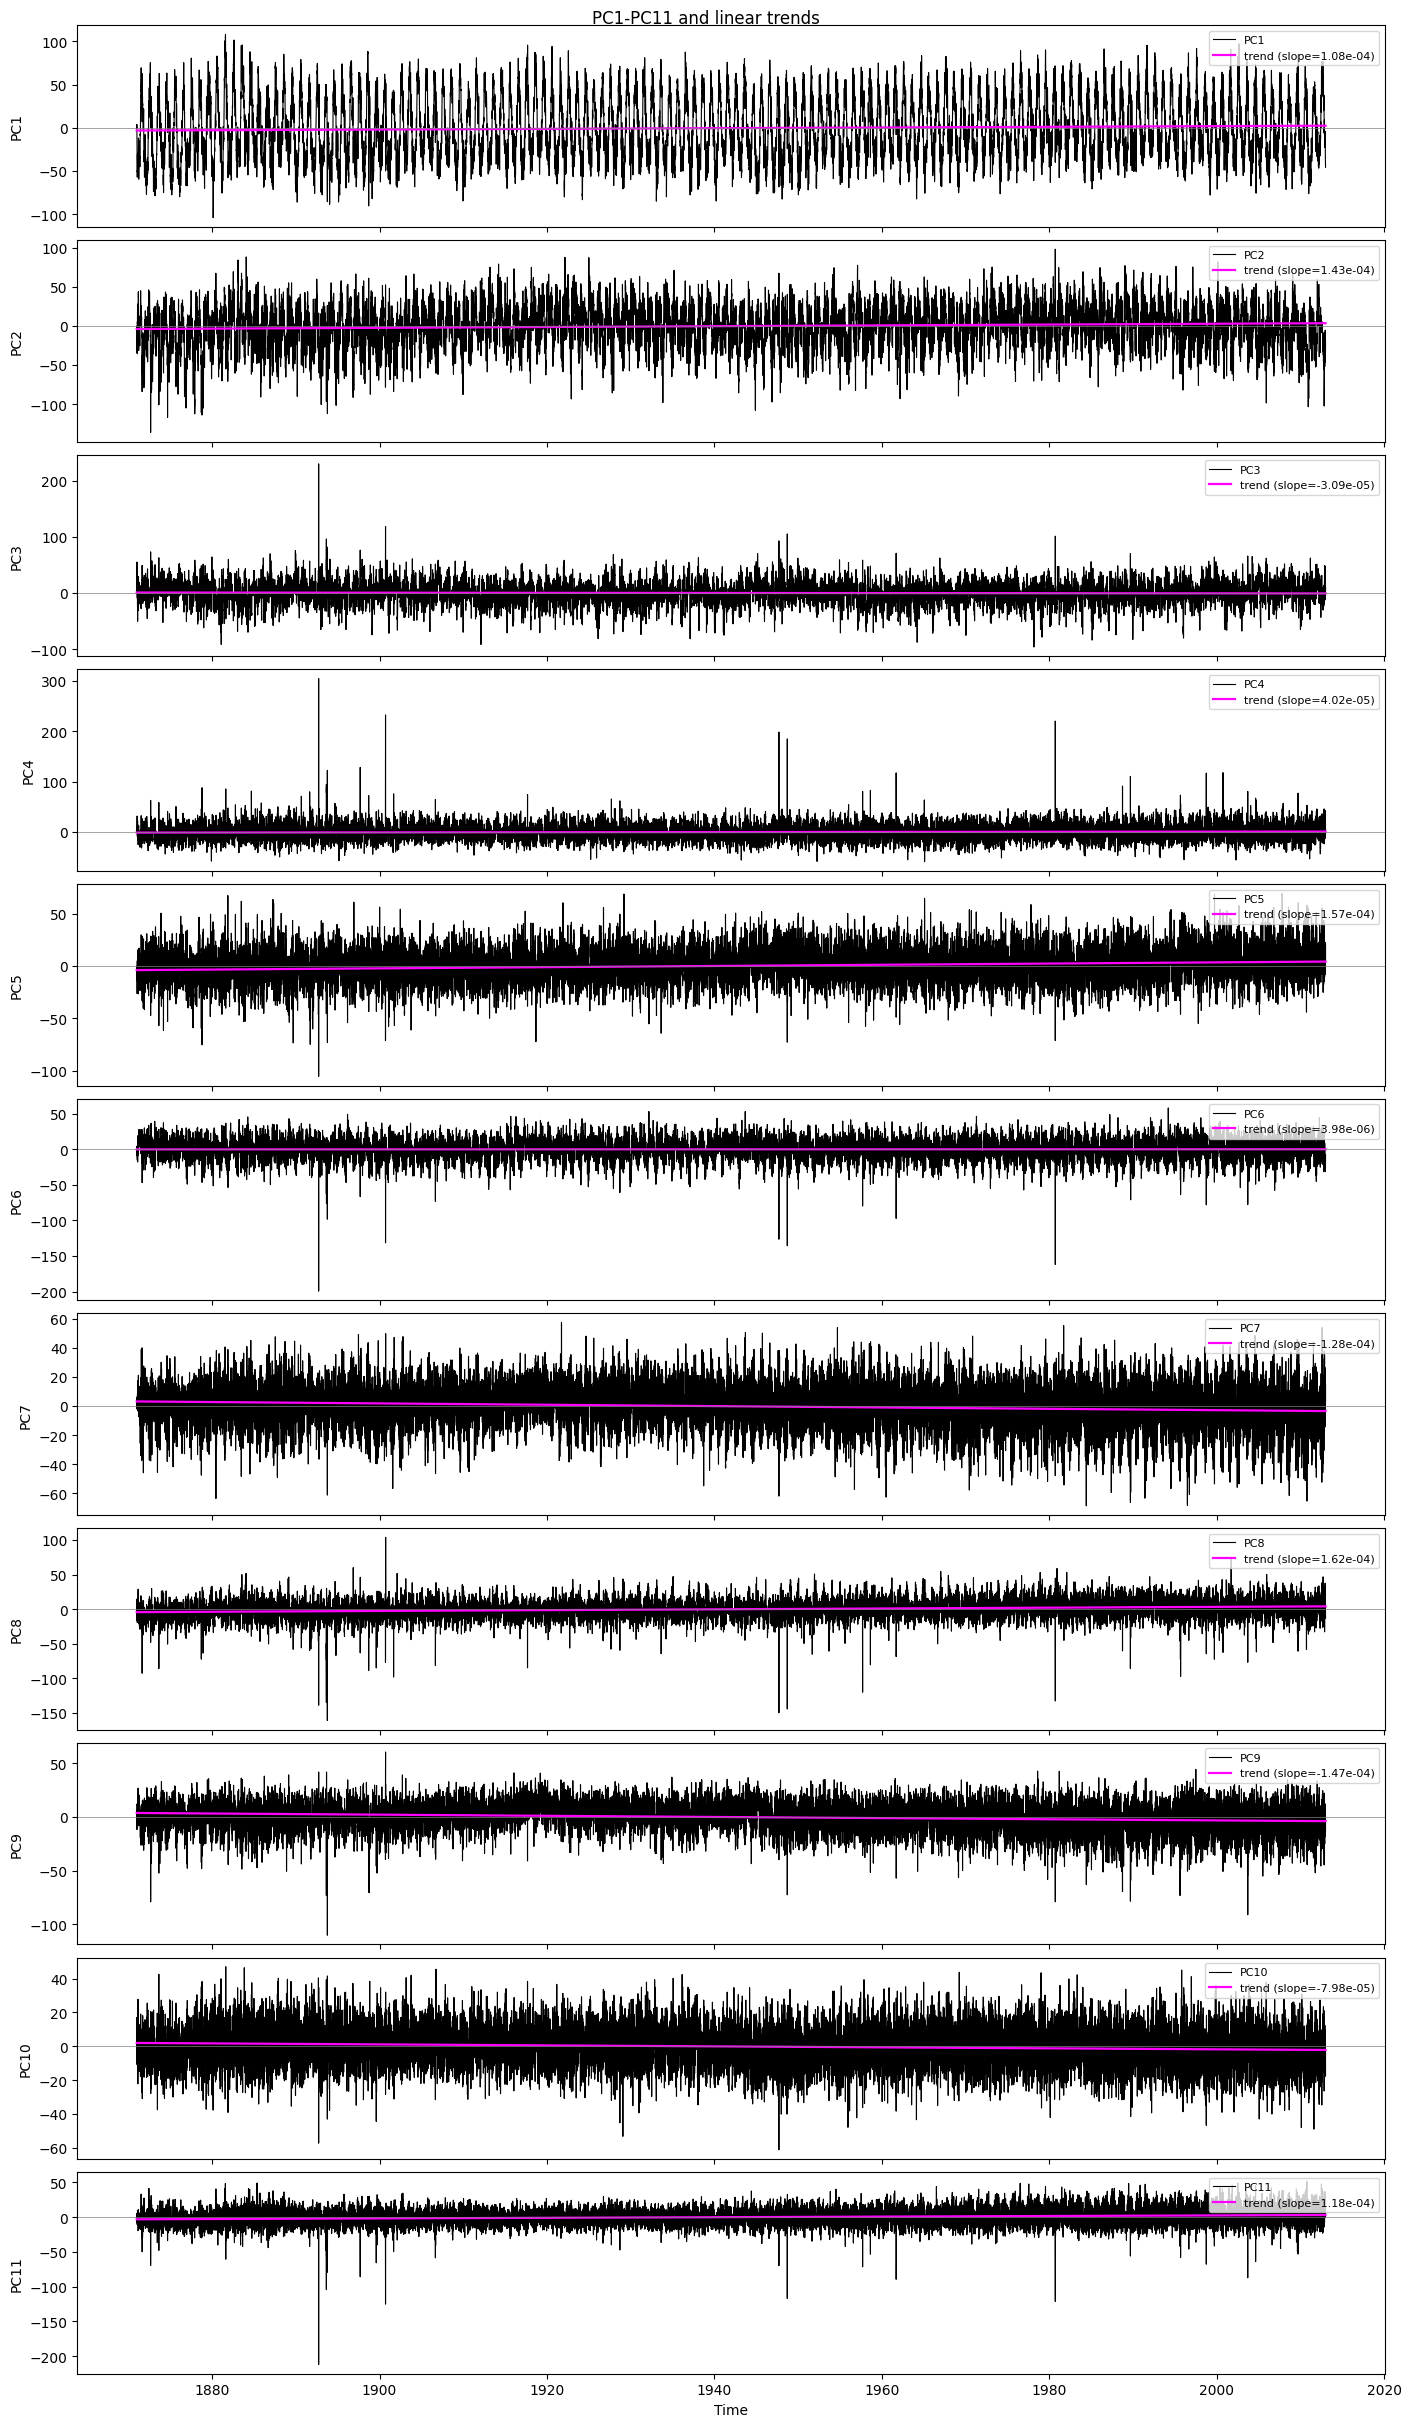

In [37]:
# Plot each PC and its linear trend in one figure (1 column x 11 rows)
import matplotlib.pyplot as plt
import numpy as np

# Use the first 11 PCs
pc_cols = list(df.columns[:11])
t = np.arange(len(df))

fig, axes = plt.subplots(nrows=11, ncols=1, figsize=(14, 24), sharex=True, constrained_layout=True)

for i, col in enumerate(pc_cols):
    y = df[col].values
    slope, intercept = np.polyfit(t, y, 1)
    y_trend = slope * t + intercept

    axes[i].plot(df.index, y, color="black", lw=0.8, label=f"{col}")
    axes[i].plot(df.index, y_trend, color="fuchsia", lw=1.6, label=f"trend (slope={slope:.2e})")
    axes[i].axhline(0, color="gray", lw=0.5)
    axes[i].set_ylabel(col)
    axes[i].legend(loc="upper right", fontsize=8)

axes[-1].set_xlabel("Time")
fig.suptitle("PC1-PC11 and linear trends", y=1.005)
plt.show()

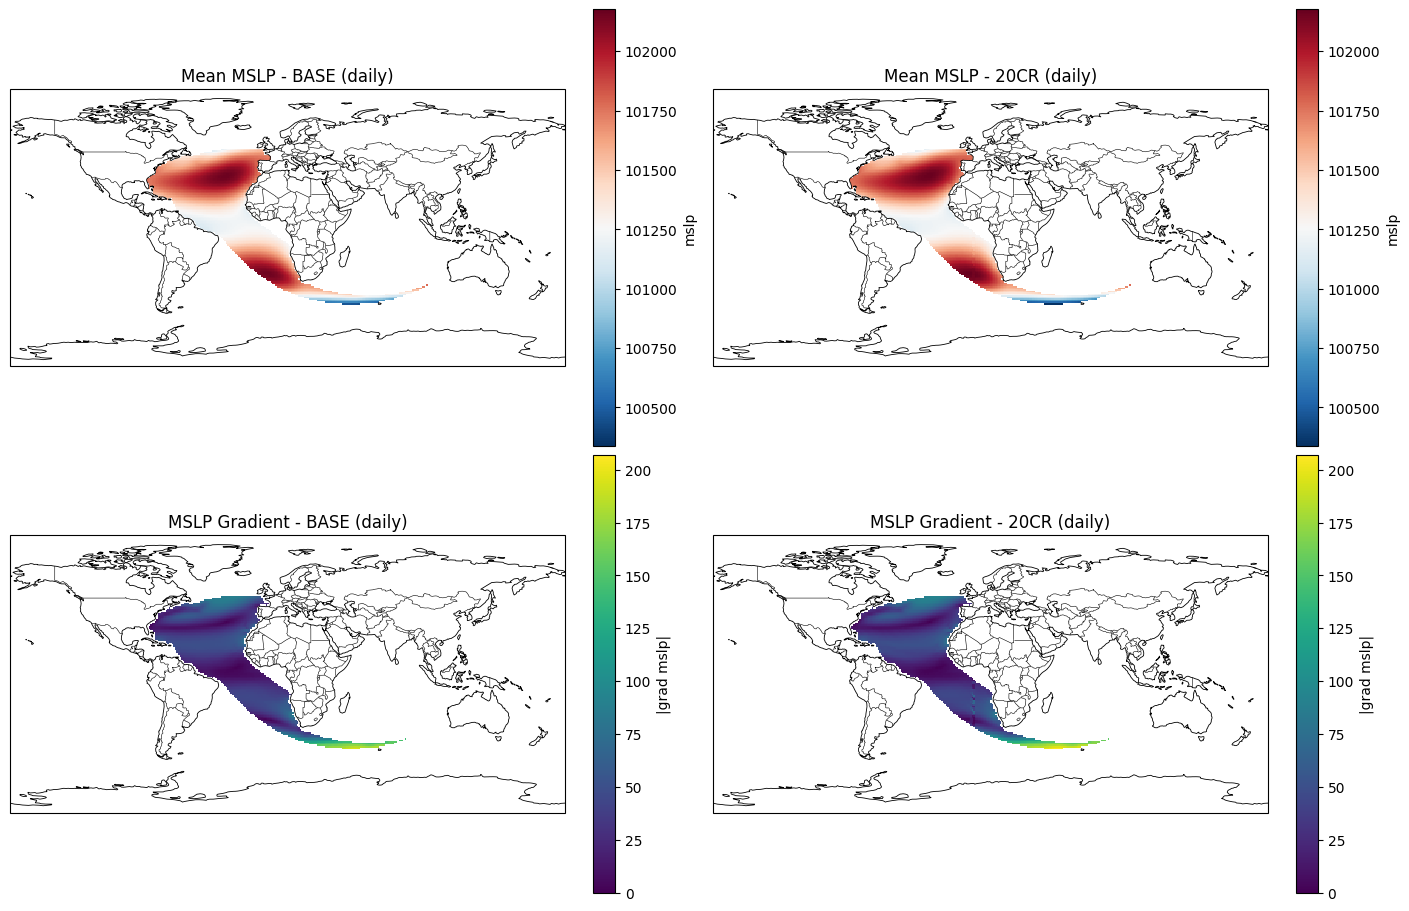

In [38]:
frequency = "daily"

import cartopy.crs as ccrs
import cartopy.feature as cfeature


def to_freq(ds: xr.Dataset, freq: str) -> xr.Dataset:
    if freq == "daily":
        return ds
    return ds.resample(time="MS").mean()


def grad_mag(da: xr.DataArray) -> xr.DataArray:
    dlat = float(np.abs(da.latitude[1] - da.latitude[0]))
    dlon = float(np.abs(da.longitude[1] - da.longitude[0]))
    gy, gx = np.gradient(da.values, dlat, dlon)  # d/dlat, d/dlon
    return xr.DataArray(
        np.sqrt(gx**2 + gy**2),
        coords={"latitude": da.latitude, "longitude": da.longitude},
        dims=("latitude", "longitude"),
    )


# --- Load BASE + NEW (daily, MSLP only) ---
base = data_slp
new = mslp_20cr_std

# Ensure we are working with xarray objects (your run can sometimes hold pandas DataFrames)
import pandas as pd


def ensure_xarray(obj: object) -> xr.Dataset:
    if isinstance(obj, xr.Dataset):
        return obj

    if isinstance(obj, pd.DataFrame):
        df = obj

        # If time/lat/lon are columns, create a MultiIndex.
        if {"time", "latitude", "longitude"}.issubset(df.columns):
            df = df.set_index(["time", "latitude", "longitude"])

        if isinstance(df.index, pd.MultiIndex):
            # If names are missing/unknown, assume (time, latitude, longitude) order.
            if list(df.index.names) != ["time", "latitude", "longitude"]:
                df = df.copy()
                df.index = df.index.set_names(["time", "latitude", "longitude"])

            return xr.Dataset.from_dataframe(df)

        raise ValueError("DataFrame must include (time, latitude, longitude) to convert to xarray")

    return obj


base = ensure_xarray(base)
new = ensure_xarray(new)

# Keep only vars available in both
vars_to_plot = ["mslp"]

# Align period
t0 = max(base.time.values.min(), new.time.values.min())
t1 = min(base.time.values.max(), new.time.values.max())
base = base.sel(time=slice(t0, t1))
new = new.sel(time=slice(t0, t1))

# Align grid
base = base.interp(latitude=new.latitude, longitude=new.longitude, method="nearest")

# Build means + gradients
mean_base = {v: base[v].mean("time") for v in vars_to_plot}
mean_new = {v: new[v].mean("time") for v in vars_to_plot}
grad_base = {v: grad_mag(mean_base[v]) for v in vars_to_plot}
grad_new = {v: grad_mag(mean_new[v]) for v in vars_to_plot}

# Put USA on the left side of map (adjust as needed)
map_center_lon = 10
map_crs = ccrs.PlateCarree(central_longitude=map_center_lon)
data_crs = ccrs.PlateCarree()

lat_min = float(new.latitude.min())
lat_max = float(new.latitude.max())
lon_min = float(new.longitude.min())
lon_max = float(new.longitude.max())

# Dynamic layout: 2 rows per variable (mean + gradient), 2 columns (base vs new)
nvars = len(vars_to_plot)
fig, axes = plt.subplots(
    2 * nvars,
    2,
    figsize=(14, 4.5 * 2 * nvars),
    constrained_layout=True,
    subplot_kw={"projection": map_crs},
)
axes = np.atleast_2d(axes)

for iv, v in enumerate(vars_to_plot):
    r_mean = 2 * iv
    r_grad = r_mean + 1

    # Mean maps
    vmin = np.nanmin([mean_base[v].values, mean_new[v].values])
    vmax = np.nanmax([mean_base[v].values, mean_new[v].values])

    im = axes[r_mean, 0].pcolormesh(
        mean_base[v].longitude,
        mean_base[v].latitude,
        mean_base[v],
        transform=data_crs,
        shading="auto",
        cmap="RdBu_r",
        vmin=vmin,
        vmax=vmax,
    )
    axes[r_mean, 0].set_title(f"Mean {v.upper()} - BASE ({frequency})")
    fig.colorbar(im, ax=axes[r_mean, 0], label=v)

    im = axes[r_mean, 1].pcolormesh(
        mean_new[v].longitude,
        mean_new[v].latitude,
        mean_new[v],
        transform=data_crs,
        shading="auto",
        cmap="RdBu_r",
        vmin=vmin,
        vmax=vmax,
    )
    axes[r_mean, 1].set_title(f"Mean {v.upper()} - 20CR ({frequency})")
    fig.colorbar(im, ax=axes[r_mean, 1], label=v)

    # Gradient maps
    gmin = 0.0
    gmax = np.nanmax([grad_base[v].values, grad_new[v].values])

    im = axes[r_grad, 0].pcolormesh(
        grad_base[v].longitude,
        grad_base[v].latitude,
        grad_base[v],
        transform=data_crs,
        shading="auto",
        cmap="viridis",
        vmin=gmin,
        vmax=gmax,
    )
    axes[r_grad, 0].set_title(f"{v.upper()} Gradient - BASE ({frequency})")
    fig.colorbar(im, ax=axes[r_grad, 0], label=f"|grad {v}|")

    im = axes[r_grad, 1].pcolormesh(
        grad_new[v].longitude,
        grad_new[v].latitude,
        grad_new[v],
        transform=data_crs,
        shading="auto",
        cmap="viridis",
        vmin=gmin,
        vmax=gmax,
    )
    axes[r_grad, 1].set_title(f"{v.upper()} Gradient - 20CR ({frequency})")
    fig.colorbar(im, ax=axes[r_grad, 1], label=f"|grad {v}|")


for ax in axes.ravel():
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=data_crs)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
    ax.add_feature(cfeature.BORDERS, linewidth=0.4)
    ax.set_xlabel("longitude")
    ax.set_ylabel("latitude")

plt.show()


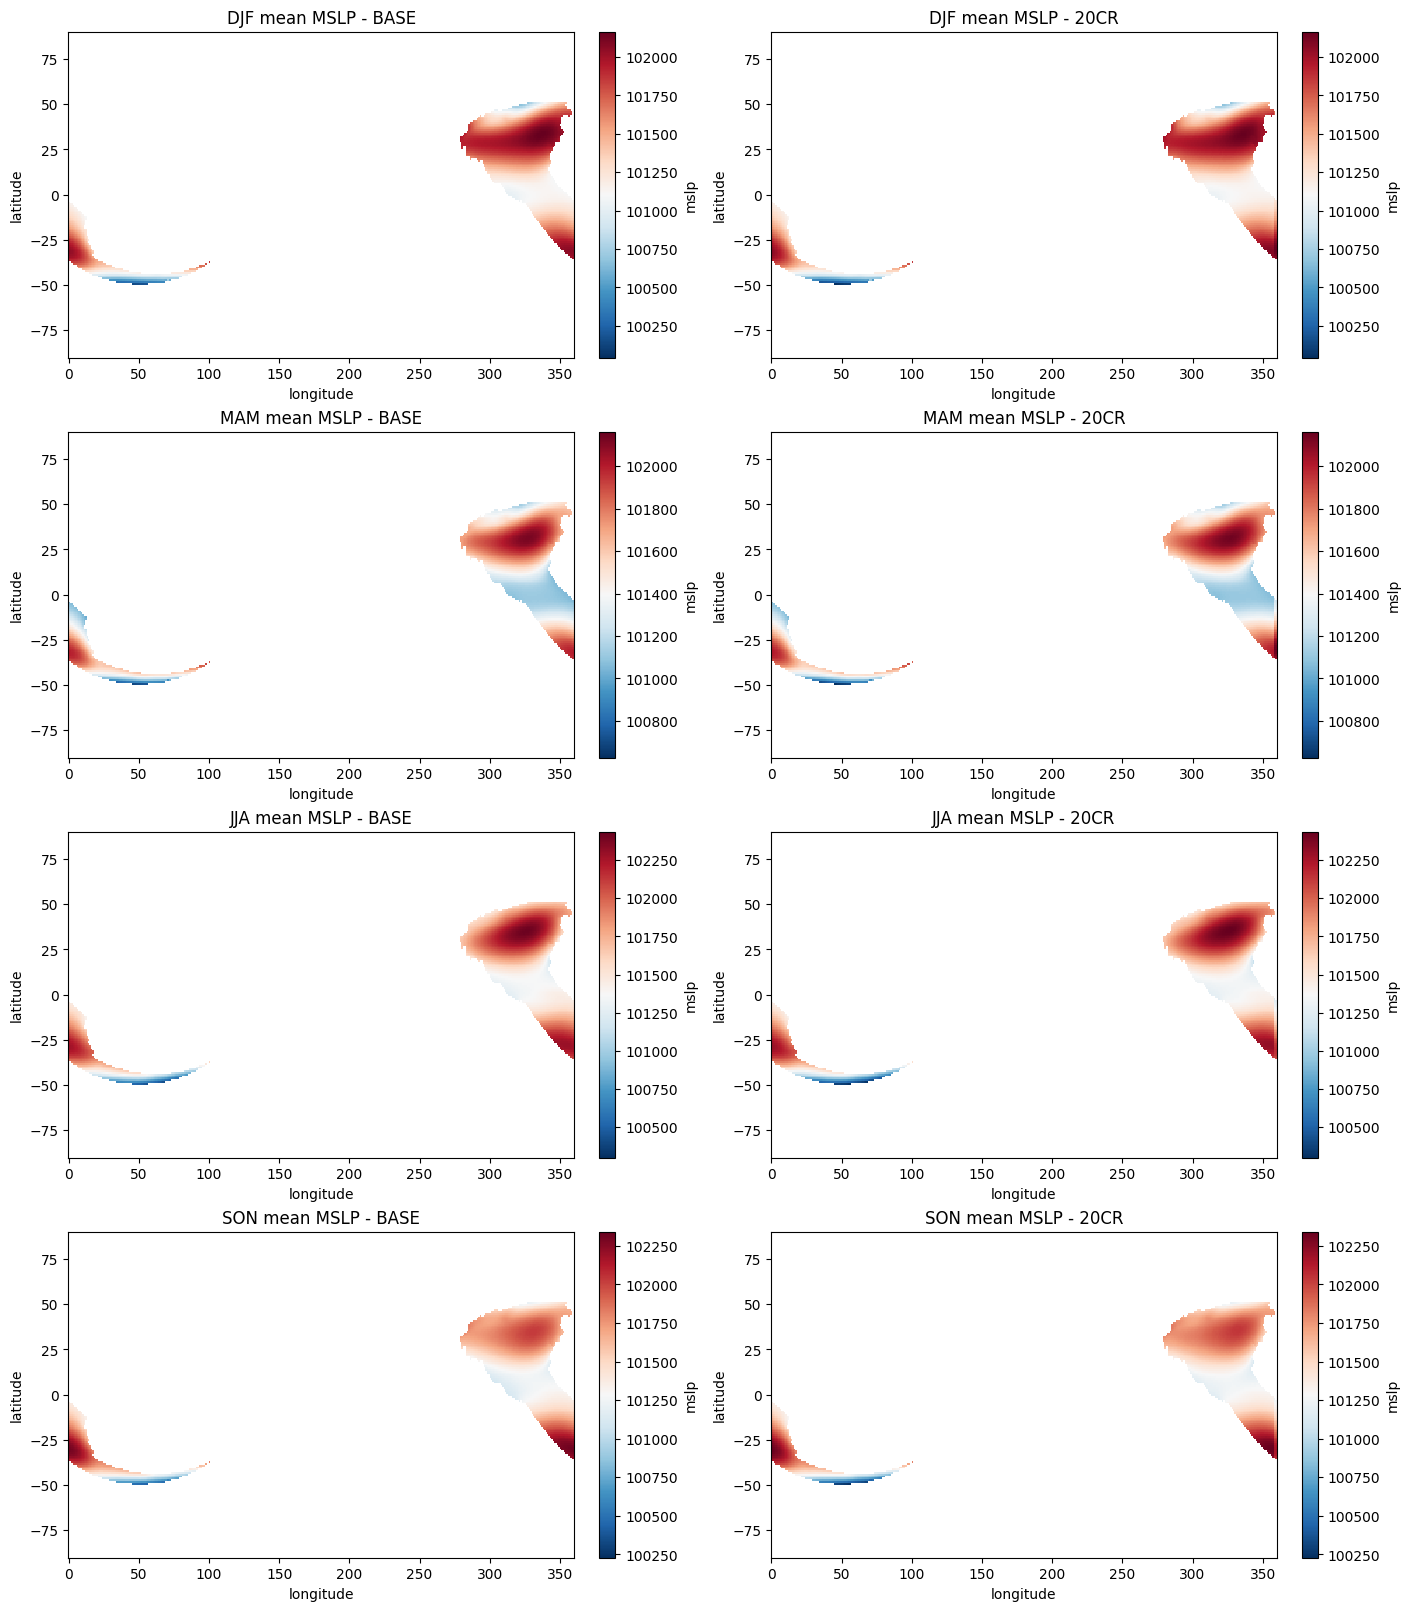

In [39]:
# Ensure we are working with xarray objects
def ensure_xarray(obj: object) -> xr.Dataset:
    if isinstance(obj, xr.Dataset):
        return obj

    if isinstance(obj, pd.DataFrame):
        df = obj
        if {"time", "latitude", "longitude"}.issubset(df.columns):
            df = df.set_index(["time", "latitude", "longitude"])

        if isinstance(df.index, pd.MultiIndex):
            if list(df.index.names) != ["time", "latitude", "longitude"]:
                df = df.copy()
                df.index = df.index.set_names(["time", "latitude", "longitude"])
            return xr.Dataset.from_dataframe(df)

        raise ValueError("DataFrame must include (time, latitude, longitude) to convert to xarray")

    raise TypeError("Expected xarray.Dataset or a convertible pandas.DataFrame")


base = ensure_xarray(data_slp)
new = ensure_xarray(mslp_20cr_std)

# Align common time window
# (daily data: we just slice both to their overlap)
t0 = max(base.time.values.min(), new.time.values.min())
t1 = min(base.time.values.max(), new.time.values.max())
base = base.sel(time=slice(t0, t1))
new = new.sel(time=slice(t0, t1))

# Align grid (interpolate BASE to 20CR grid if needed)
base = base.interp(latitude=new.latitude, longitude=new.longitude, method="nearest")

v = "mslp"

# Seasons (climatological; DJF uses Dec/Jan/Feb)
seasons = {
    "DJF": [12, 1, 2],
    "MAM": [3, 4, 5],
    "JJA": [6, 7, 8],
    "SON": [9, 10, 11],
}


def season_mean(da: xr.DataArray, months: list[int]) -> xr.DataArray:
    m = da["time"].dt.month
    mask = None
    for mo in months:
        mask = (m == mo) if mask is None else (mask | (m == mo))
    return da.where(mask, drop=True).mean("time")


fig, axes = plt.subplots(
    len(seasons),
    2,
    figsize=(14, 4.0 * len(seasons)),
    constrained_layout=True,
)
axes = np.atleast_2d(axes)

for i, (season_name, months) in enumerate(seasons.items()):
    mean_base = season_mean(base[v], months)
    mean_new = season_mean(new[v], months)

    vmin = np.nanmin([mean_base.values, mean_new.values])
    vmax = np.nanmax([mean_base.values, mean_new.values])

    im = axes[i, 0].pcolormesh(
        mean_base.longitude,
        mean_base.latitude,
        mean_base,
        shading="auto",
        cmap="RdBu_r",
        vmin=vmin,
        vmax=vmax,
    )
    axes[i, 0].set_title(f"{season_name} mean MSLP - BASE")
    fig.colorbar(im, ax=axes[i, 0], label=v)

    im = axes[i, 1].pcolormesh(
        mean_new.longitude,
        mean_new.latitude,
        mean_new,
        shading="auto",
        cmap="RdBu_r",
        vmin=vmin,
        vmax=vmax,
    )
    axes[i, 1].set_title(f"{season_name} mean MSLP - 20CR")
    fig.colorbar(im, ax=axes[i, 1], label=v)

for ax in axes.ravel():
    ax.set_xlabel("longitude")
    ax.set_ylabel("latitude")

plt.show()

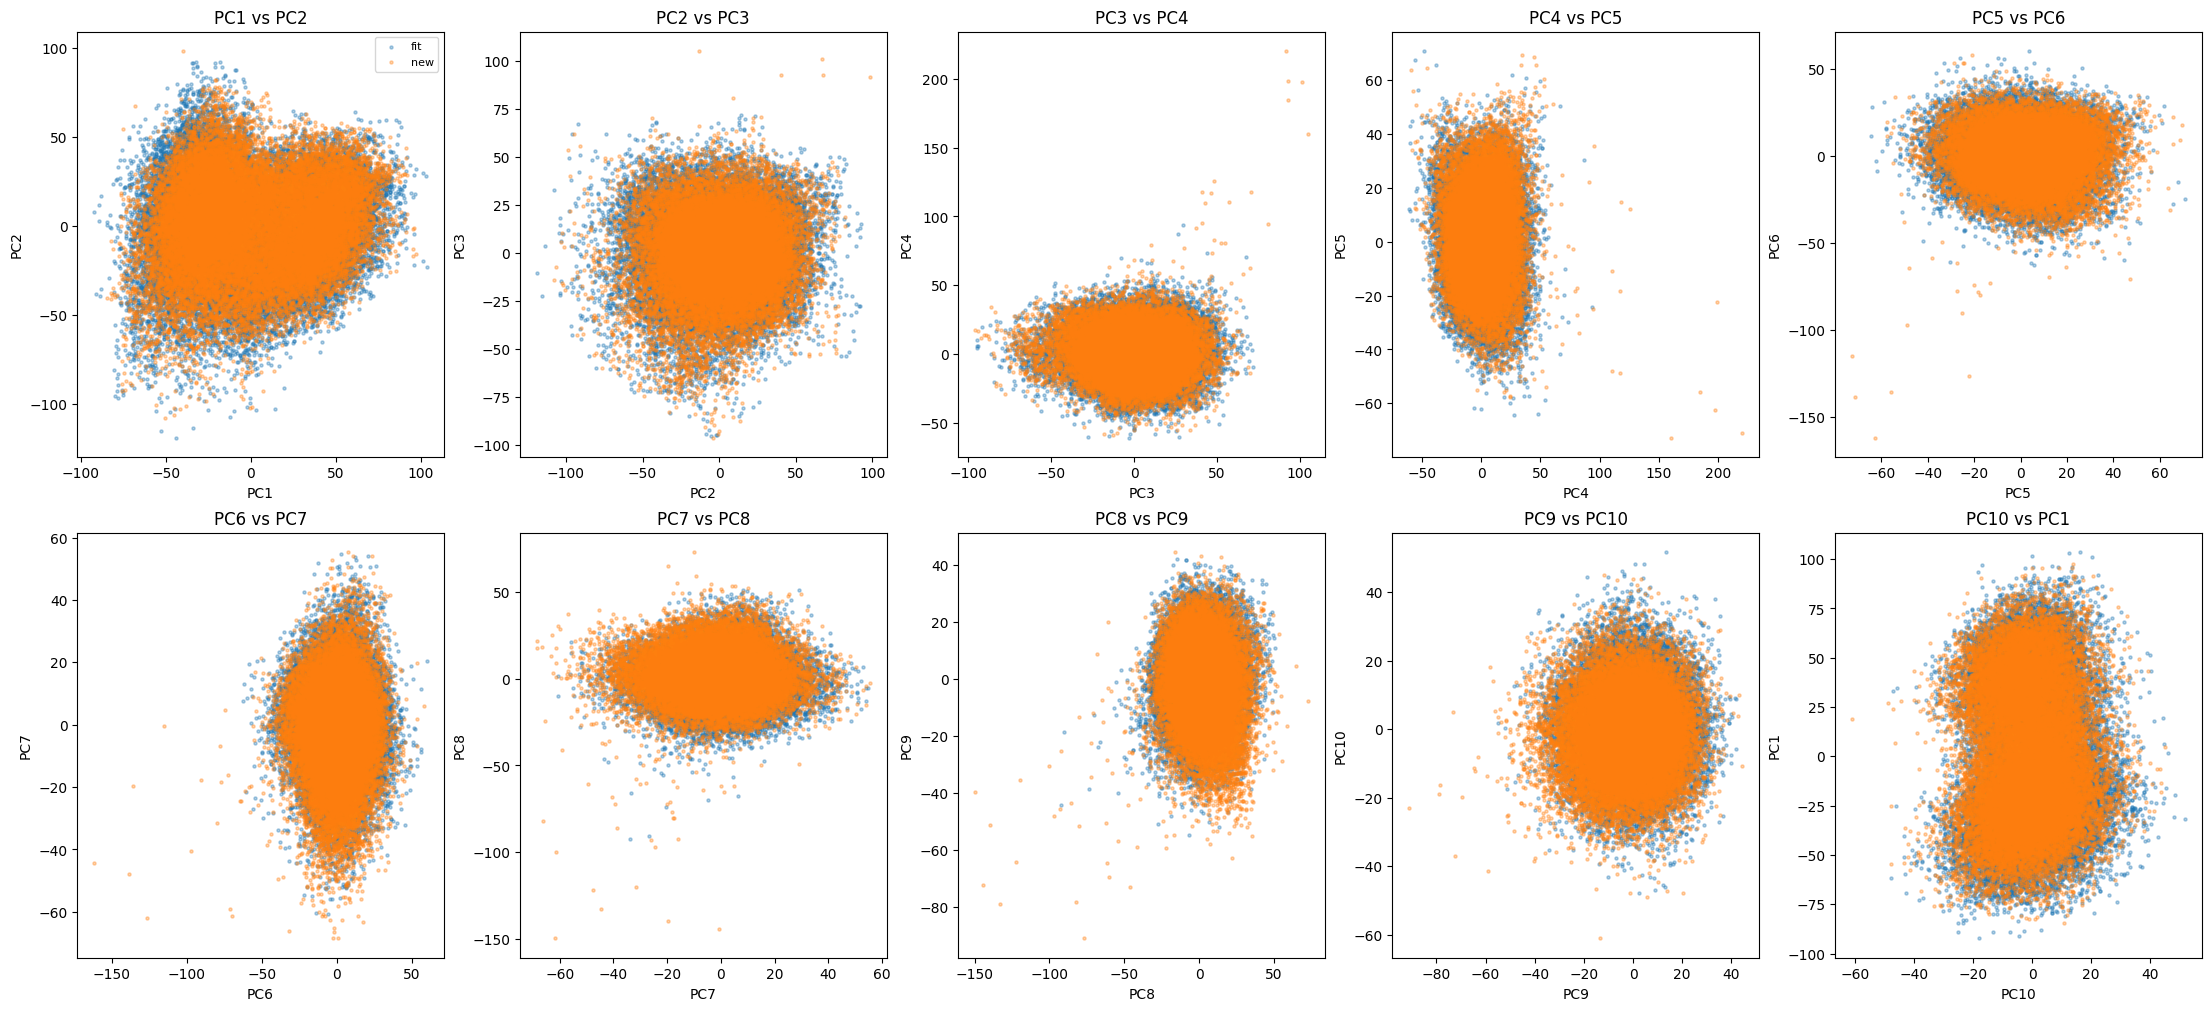

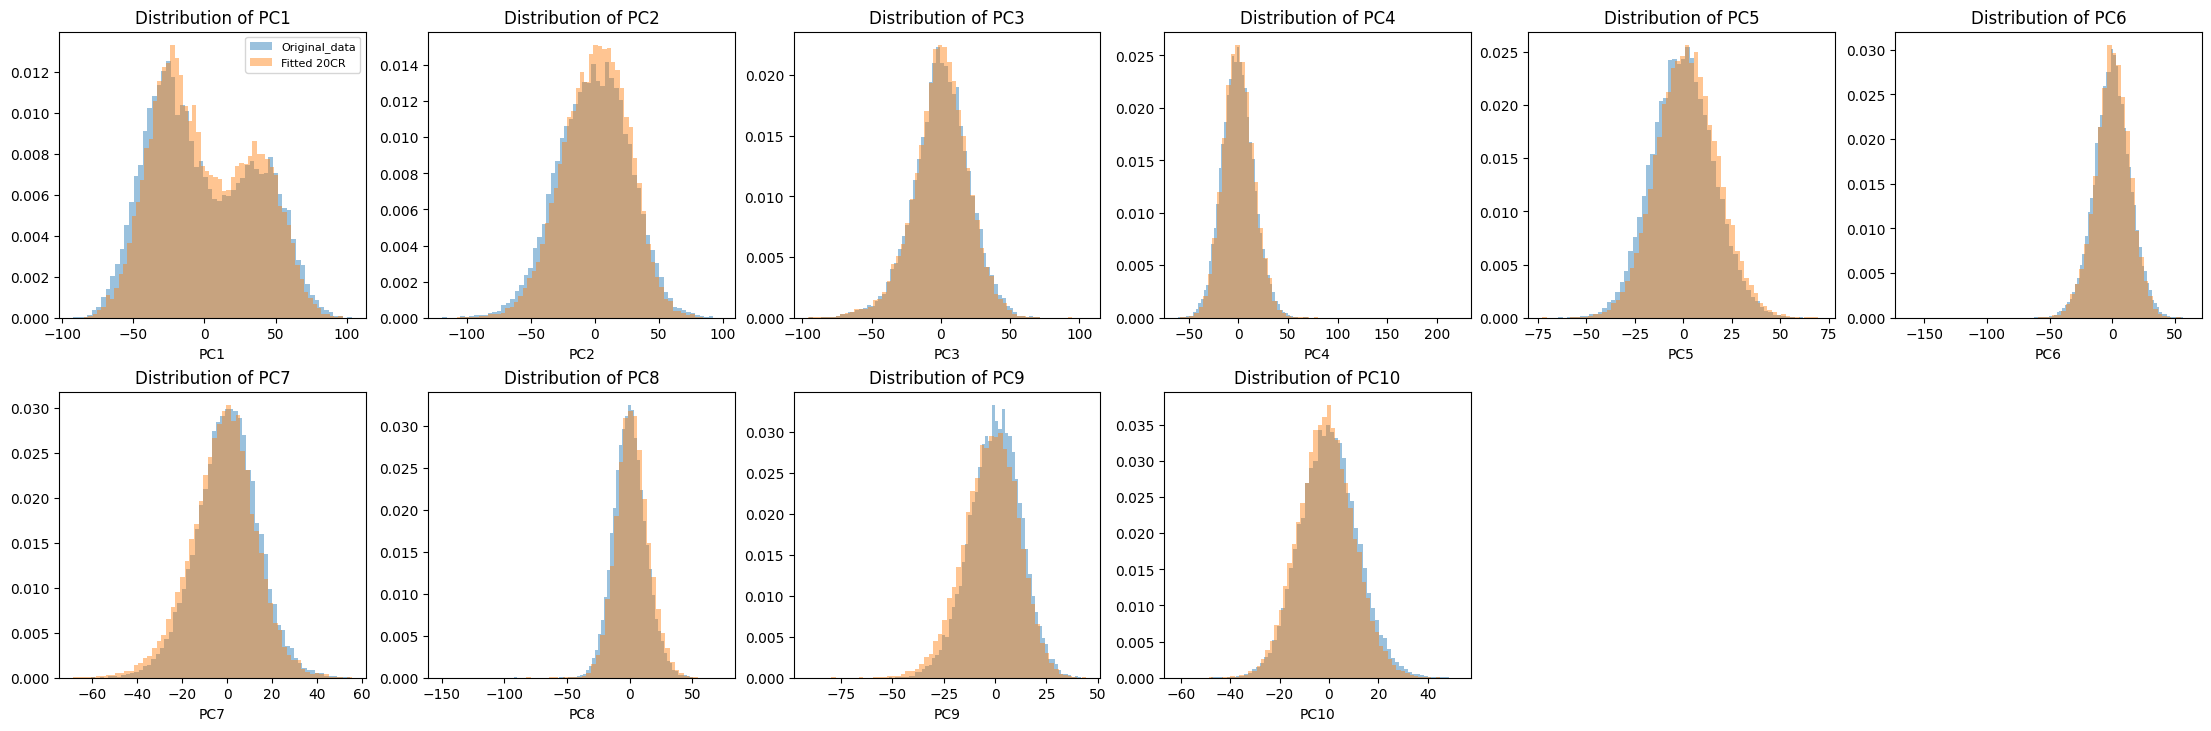

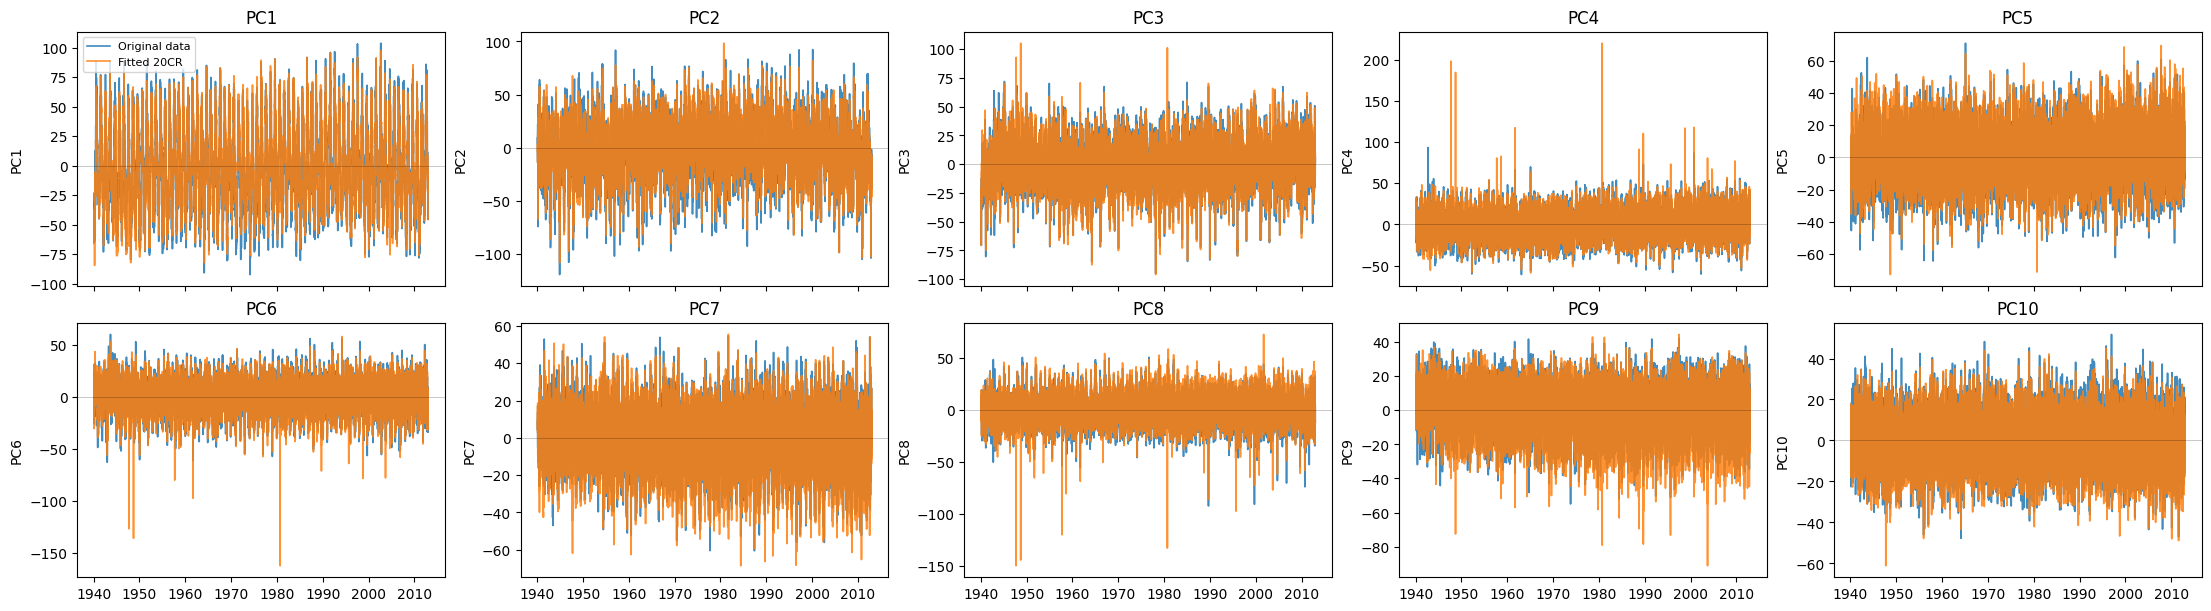

In [49]:
from utils.Pcs_plots import plot_pc_pair_scatters
from utils.Pcs_plots import plot_pc_histograms
from utils.Pcs_plots import plot_pc_time_series

plot_pc_pair_scatters(
    pca_fit=pca_mslp_fit,
    df_new=df_pcs,
    pairs=[(1, 2), (2, 3), (3, 4), (4, 5), (5, 6), (6, 7), (7, 8), (8, 9), (9, 10), (10, 1)],
    npcs=10,
    labels=("fit", "new"),
)

plot_pc_histograms(
    pca_fit=pca_mslp_fit,
    df_new=df_pcs,
    npcs=10,
    ncols=6,
    bins=60,
    labels=("Original_data", "Fitted 20CR"),
)

plot_pc_time_series(
    pca_fit=pca_mslp_fit,
    df_new=df_pcs,
    npcs=10,
    ncols=5,
    nrows=2,
    figsize=(22, 6),
    labels=("Original data", "Fitted 20CR"),
)

In [51]:
df_pcs.to_csv('/nfs/home/geocean/montanoj/New_data_Shoreshop/outputs/PCA/pcs_mslp_20cr_df.csv')
df_pcs

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC413,PC414,PC415,PC416,PC417,PC418,PC419,PC420,PC421,PC422
1871-01-01,-0.086007,-0.234905,-0.183891,0.118256,-0.307796,0.629457,-0.260849,-0.348632,-0.315842,-0.386926,...,-0.399517,-0.006635,-0.043550,0.027324,0.186573,0.074457,0.021749,-0.106527,0.085744,-0.341209
1871-01-02,-0.187273,-0.618195,-0.469747,0.505611,-0.959331,1.398849,-0.707023,-0.849267,-0.867767,-0.870079,...,-0.043545,-0.199837,0.003420,-0.023368,0.050978,0.022223,-0.117842,-0.236173,-0.004014,-0.134645
1871-01-03,-0.171758,-2.394401,-0.311508,1.524742,-2.522201,2.343110,-1.141847,-2.595708,-2.169162,0.049443,...,-0.635301,-0.317808,-0.595697,0.044560,-0.121341,-0.211656,-0.097481,0.455737,0.462362,-0.026479
1871-01-04,0.260252,-7.954070,1.481841,4.327903,-7.002630,4.265431,-1.930586,-7.968569,-5.875587,4.224694,...,-0.325275,0.659490,0.809547,0.109262,0.286208,-0.067150,-0.315534,-0.279543,-0.457101,-0.308599
1871-01-05,1.236674,-14.232229,6.509466,6.962477,-11.092649,3.279446,-1.090120,-12.042172,-8.256926,11.648436,...,0.681365,-0.732861,-0.776753,-0.600548,-0.804398,-0.543199,0.908270,-0.782035,-0.176883,1.274076
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2012-12-27,-38.098217,-37.896233,-3.336508,20.707542,10.143505,-28.806820,8.862761,6.083100,7.229842,-0.616333,...,-0.883700,1.092116,0.116902,-0.554848,-0.473234,0.401672,0.867787,-0.561231,0.165229,0.816046
2012-12-28,-38.034496,-37.159588,0.823626,13.752421,18.138474,-22.842779,8.771376,0.823844,-0.920200,-4.074412,...,-0.606757,0.397072,0.402052,-1.057688,-0.026332,-1.276077,0.076237,1.061264,0.243030,0.103405
2012-12-29,-39.570129,-31.259415,6.228447,3.368056,20.232248,-18.508675,15.085519,-9.750986,-5.175528,-3.536433,...,0.420102,0.136498,-1.097524,0.818038,-0.521606,-0.572169,0.821383,-0.641850,-0.838163,-0.007653
2012-12-30,-42.566967,-25.001511,9.830803,-4.278940,12.152595,-12.435157,11.874052,-13.444093,-11.801994,-10.414918,...,0.364739,-1.250391,0.767592,-0.377003,-1.007587,0.548471,0.415854,1.763512,0.682911,0.406491


PC1: clipped 11 out-of-range values (range=[-92.28, 103.65])
PC2: clipped 2 out-of-range values (range=[-119.06, 97.63])
PC3: clipped 18 out-of-range values (range=[-95.13, 71.95])
PC4: clipped 20 out-of-range values (range=[-60.86, 98.94])
PC5: clipped 15 out-of-range values (range=[-64.37, 70.87])
PC6: clipped 28 out-of-range values (range=[-62.59, 60.22])
PC7: clipped 7 out-of-range values (range=[-63.93, 54.59])
PC8: clipped 37 out-of-range values (range=[-92.15, 50.91])
PC9: clipped 34 out-of-range values (range=[-54.93, 46.00])
PC10: clipped 6 out-of-range values (range=[-47.75, 51.77])
PC11: clipped 21 out-of-range values (range=[-69.47, 49.93])
PC12: clipped 16 out-of-range values (range=[-33.20, 135.79])
PC13: clipped 25 out-of-range values (range=[-74.21, 42.48])
PC14: clipped 4 out-of-range values (range=[-41.84, 63.96])
PC15: clipped 29 out-of-range values (range=[-51.09, 52.94])
PC16: clipped 20 out-of-range values (range=[-36.24, 233.88])
PC17: clipped 19 out-of-range val

PC96: clipped 5 out-of-range values (range=[-42.10, 54.40])
PC97: clipped 3 out-of-range values (range=[-87.89, 62.69])
PC98: clipped 8 out-of-range values (range=[-53.39, 42.48])
PC99: clipped 4 out-of-range values (range=[-41.92, 66.00])
PC100: clipped 4 out-of-range values (range=[-65.50, 85.51])
PC101: clipped 11 out-of-range values (range=[-51.66, 51.59])
PC102: clipped 1 out-of-range values (range=[-75.48, 69.14])
PC103: clipped 2 out-of-range values (range=[-57.40, 57.13])
PC104: clipped 0 out-of-range values (range=[-71.41, 99.85])
PC105: clipped 0 out-of-range values (range=[-68.06, 74.66])
PC106: clipped 1 out-of-range values (range=[-63.98, 78.90])
PC107: clipped 0 out-of-range values (range=[-111.77, 48.47])
PC108: clipped 6 out-of-range values (range=[-73.29, 44.04])
PC109: clipped 1 out-of-range values (range=[-80.67, 79.14])
PC110: clipped 0 out-of-range values (range=[-66.48, 66.21])
PC111: clipped 0 out-of-range values (range=[-53.28, 66.89])
PC112: clipped 0 out-of-ra

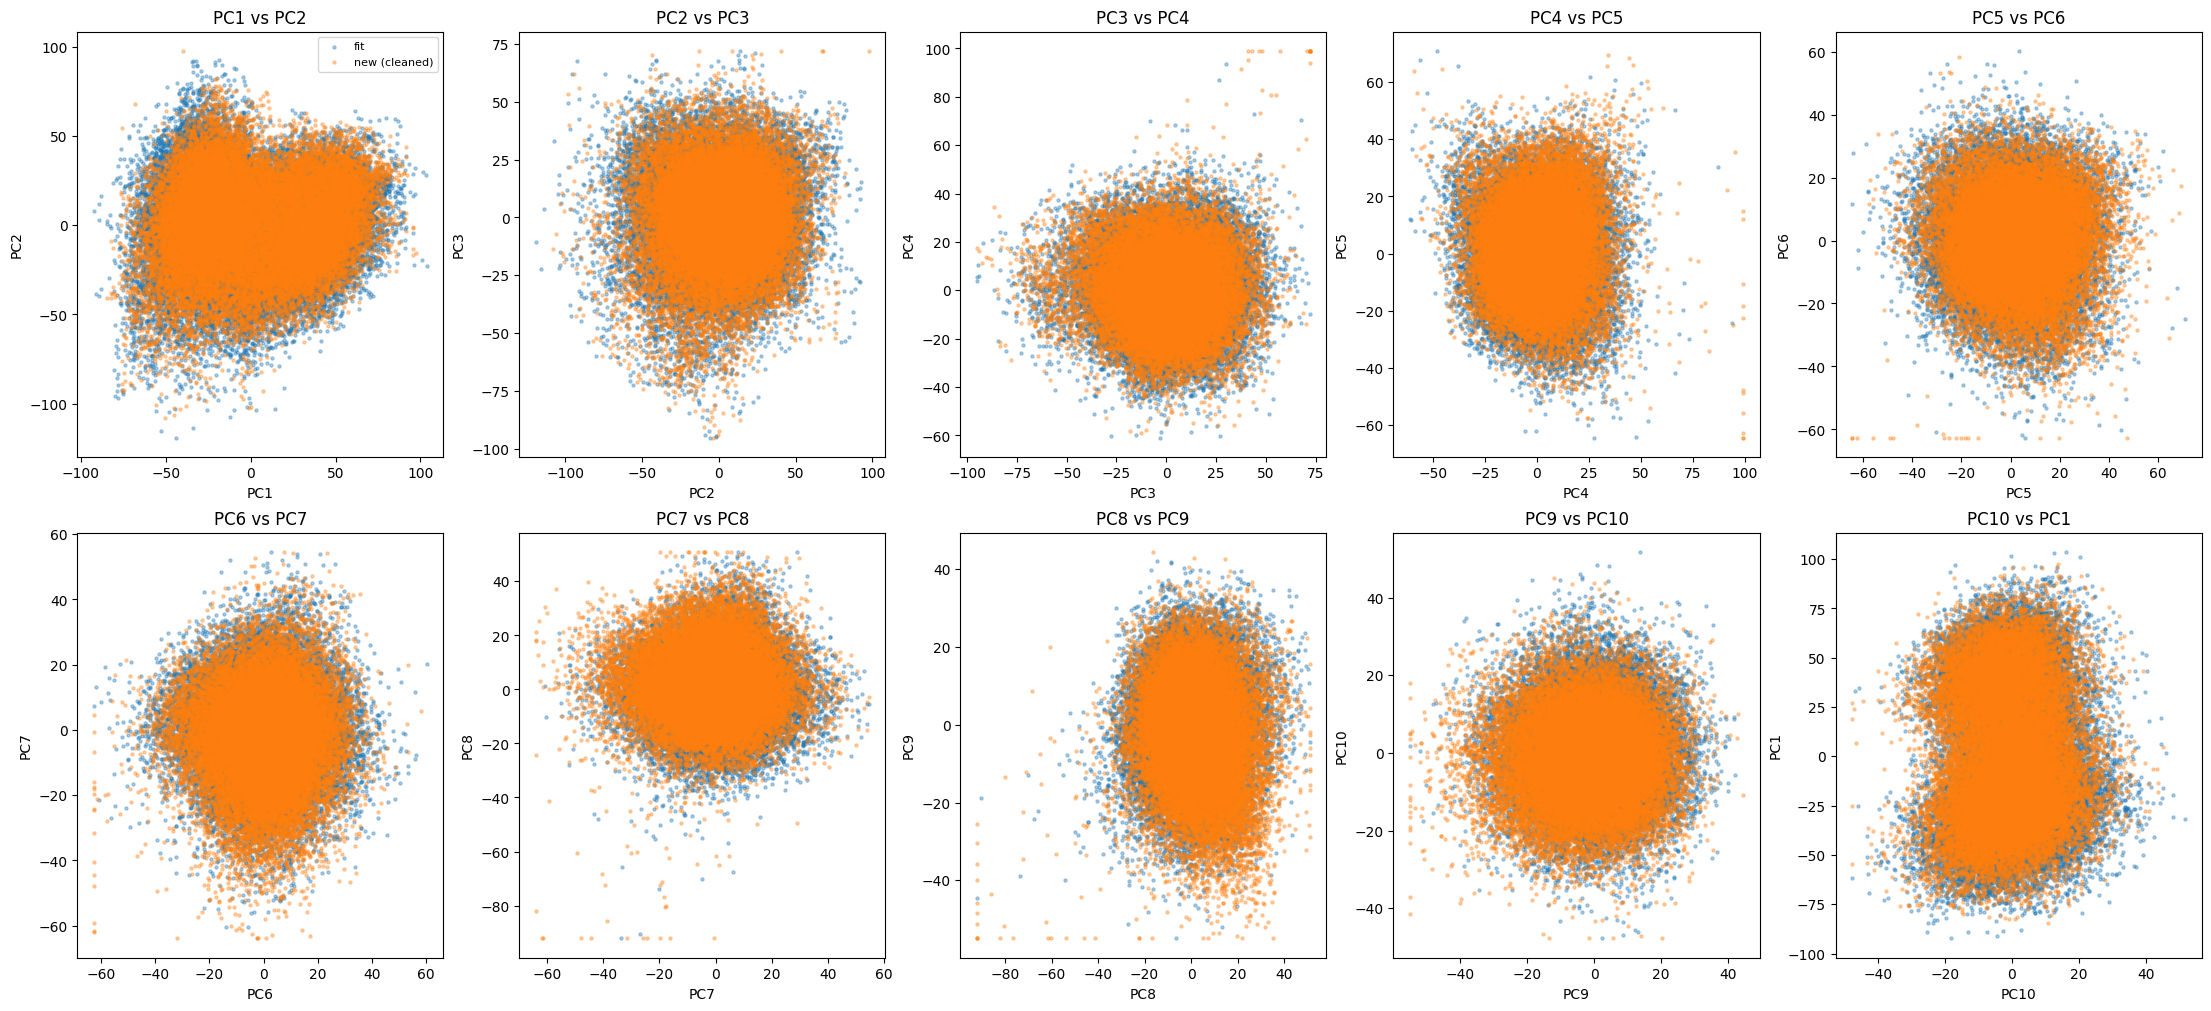

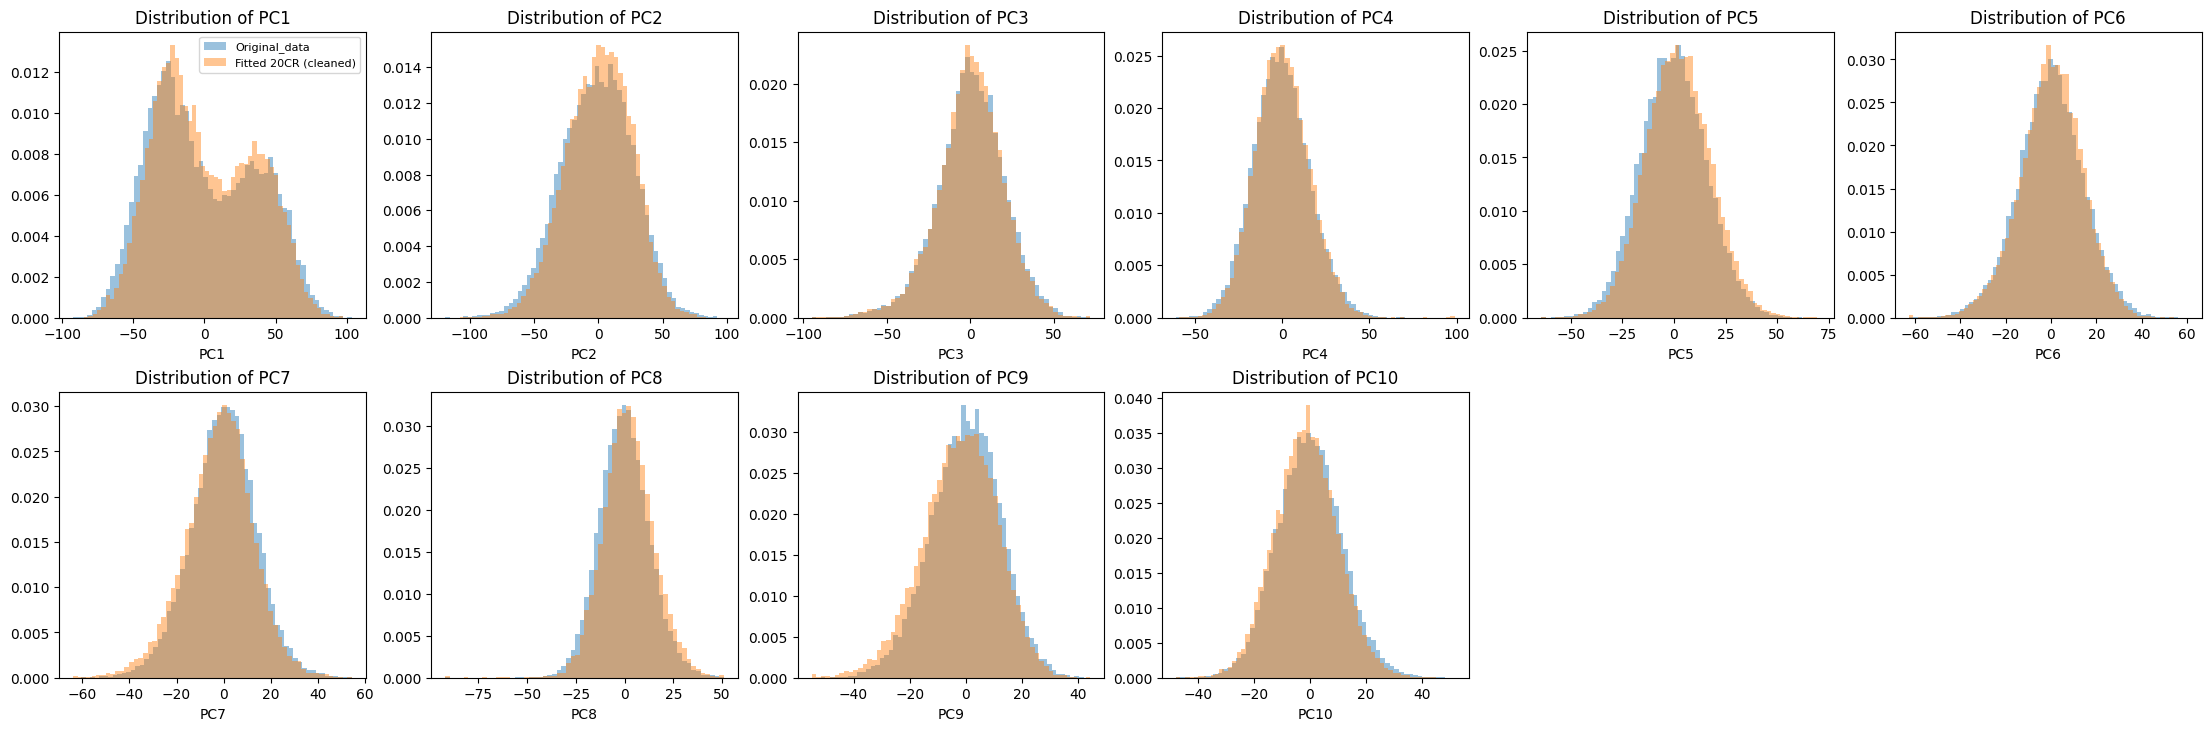

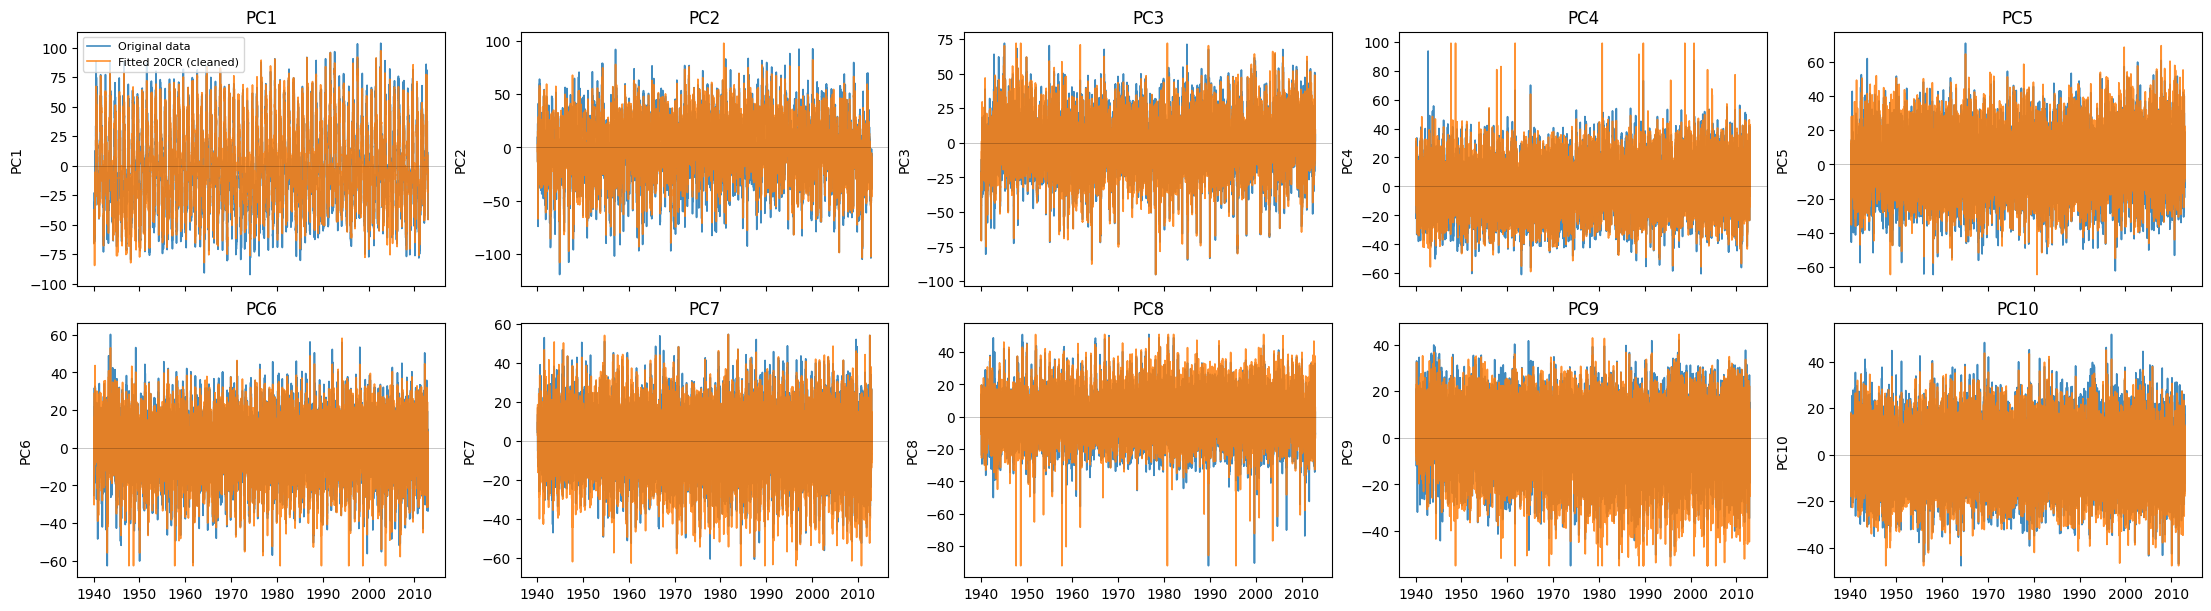

In [52]:
from utils.Pcs_plots import plot_pc_pair_scatters
from utils.Pcs_plots import plot_pc_histograms
from utils.Pcs_plots import plot_pc_time_series

# Replace unrealistically large synthetic values with the original fitted PCs.
df_ref = pca_mslp_fit.pcs_df.copy()
df_ref.index = pd.to_datetime(df_ref.index)

df_pcs_clean = df_pcs.copy()
df_pcs_clean.index = pd.to_datetime(df_pcs_clean.index)

pc_cols = sorted([c for c in df_ref.columns.intersection(df_pcs_clean.columns) if c.startswith("PC")], key=lambda x: int(x[2:]))

for col in pc_cols:
    ref_col = df_ref[col].dropna()
    new_col = df_pcs_clean[col]

    # Hard range filter over ALL 20CR timestamps (not only overlap period).
    ref_min = ref_col.min()
    ref_max = ref_col.max()
    extreme_mask = (new_col < ref_min) | (new_col > ref_max)

    # Clip to original range when outside bounds.
    n_replaced = int(extreme_mask.sum())
    df_pcs_clean[col] = new_col.clip(lower=ref_min, upper=ref_max)
    print(f"{col}: clipped {n_replaced} out-of-range values (range=[{ref_min:.2f}, {ref_max:.2f}])")

# Named output for downstream steps.
pcs_20cr_corrected = df_pcs_clean.copy()

plot_pc_pair_scatters(
    pca_fit=pca_mslp_fit,
    df_new=df_pcs_clean,
    pairs=[(1, 2), (2, 3), (3, 4), (4, 5), (5, 6), (6, 7), (7, 8), (8, 9), (9, 10), (10, 1)],
    npcs=10,
    labels=("fit", "new (cleaned)"),
)

plot_pc_histograms(
    pca_fit=pca_mslp_fit,
    df_new=df_pcs_clean,
    npcs=10,
    ncols=6,
    bins=60,
    labels=("Original_data", "Fitted 20CR (cleaned)"),
)

plot_pc_time_series(
    pca_fit=pca_mslp_fit,
    df_new=df_pcs_clean,
    npcs=10,
    ncols=5,
    nrows=2,
    figsize=(22, 6),
    labels=("Original data", "Fitted 20CR (cleaned)"),
)

In [53]:
pcs_20cr_corrected.to_csv('/nfs/home/geocean/montanoj/New_data_Shoreshop/outputs/PCA/pcs_mslp_20cr_df_corrected.csv')

Saved joined PCs to: outputs/PCA/20cr_era5_pcs.csv
Joined period: 1871-01-01 -> 2023-11-22


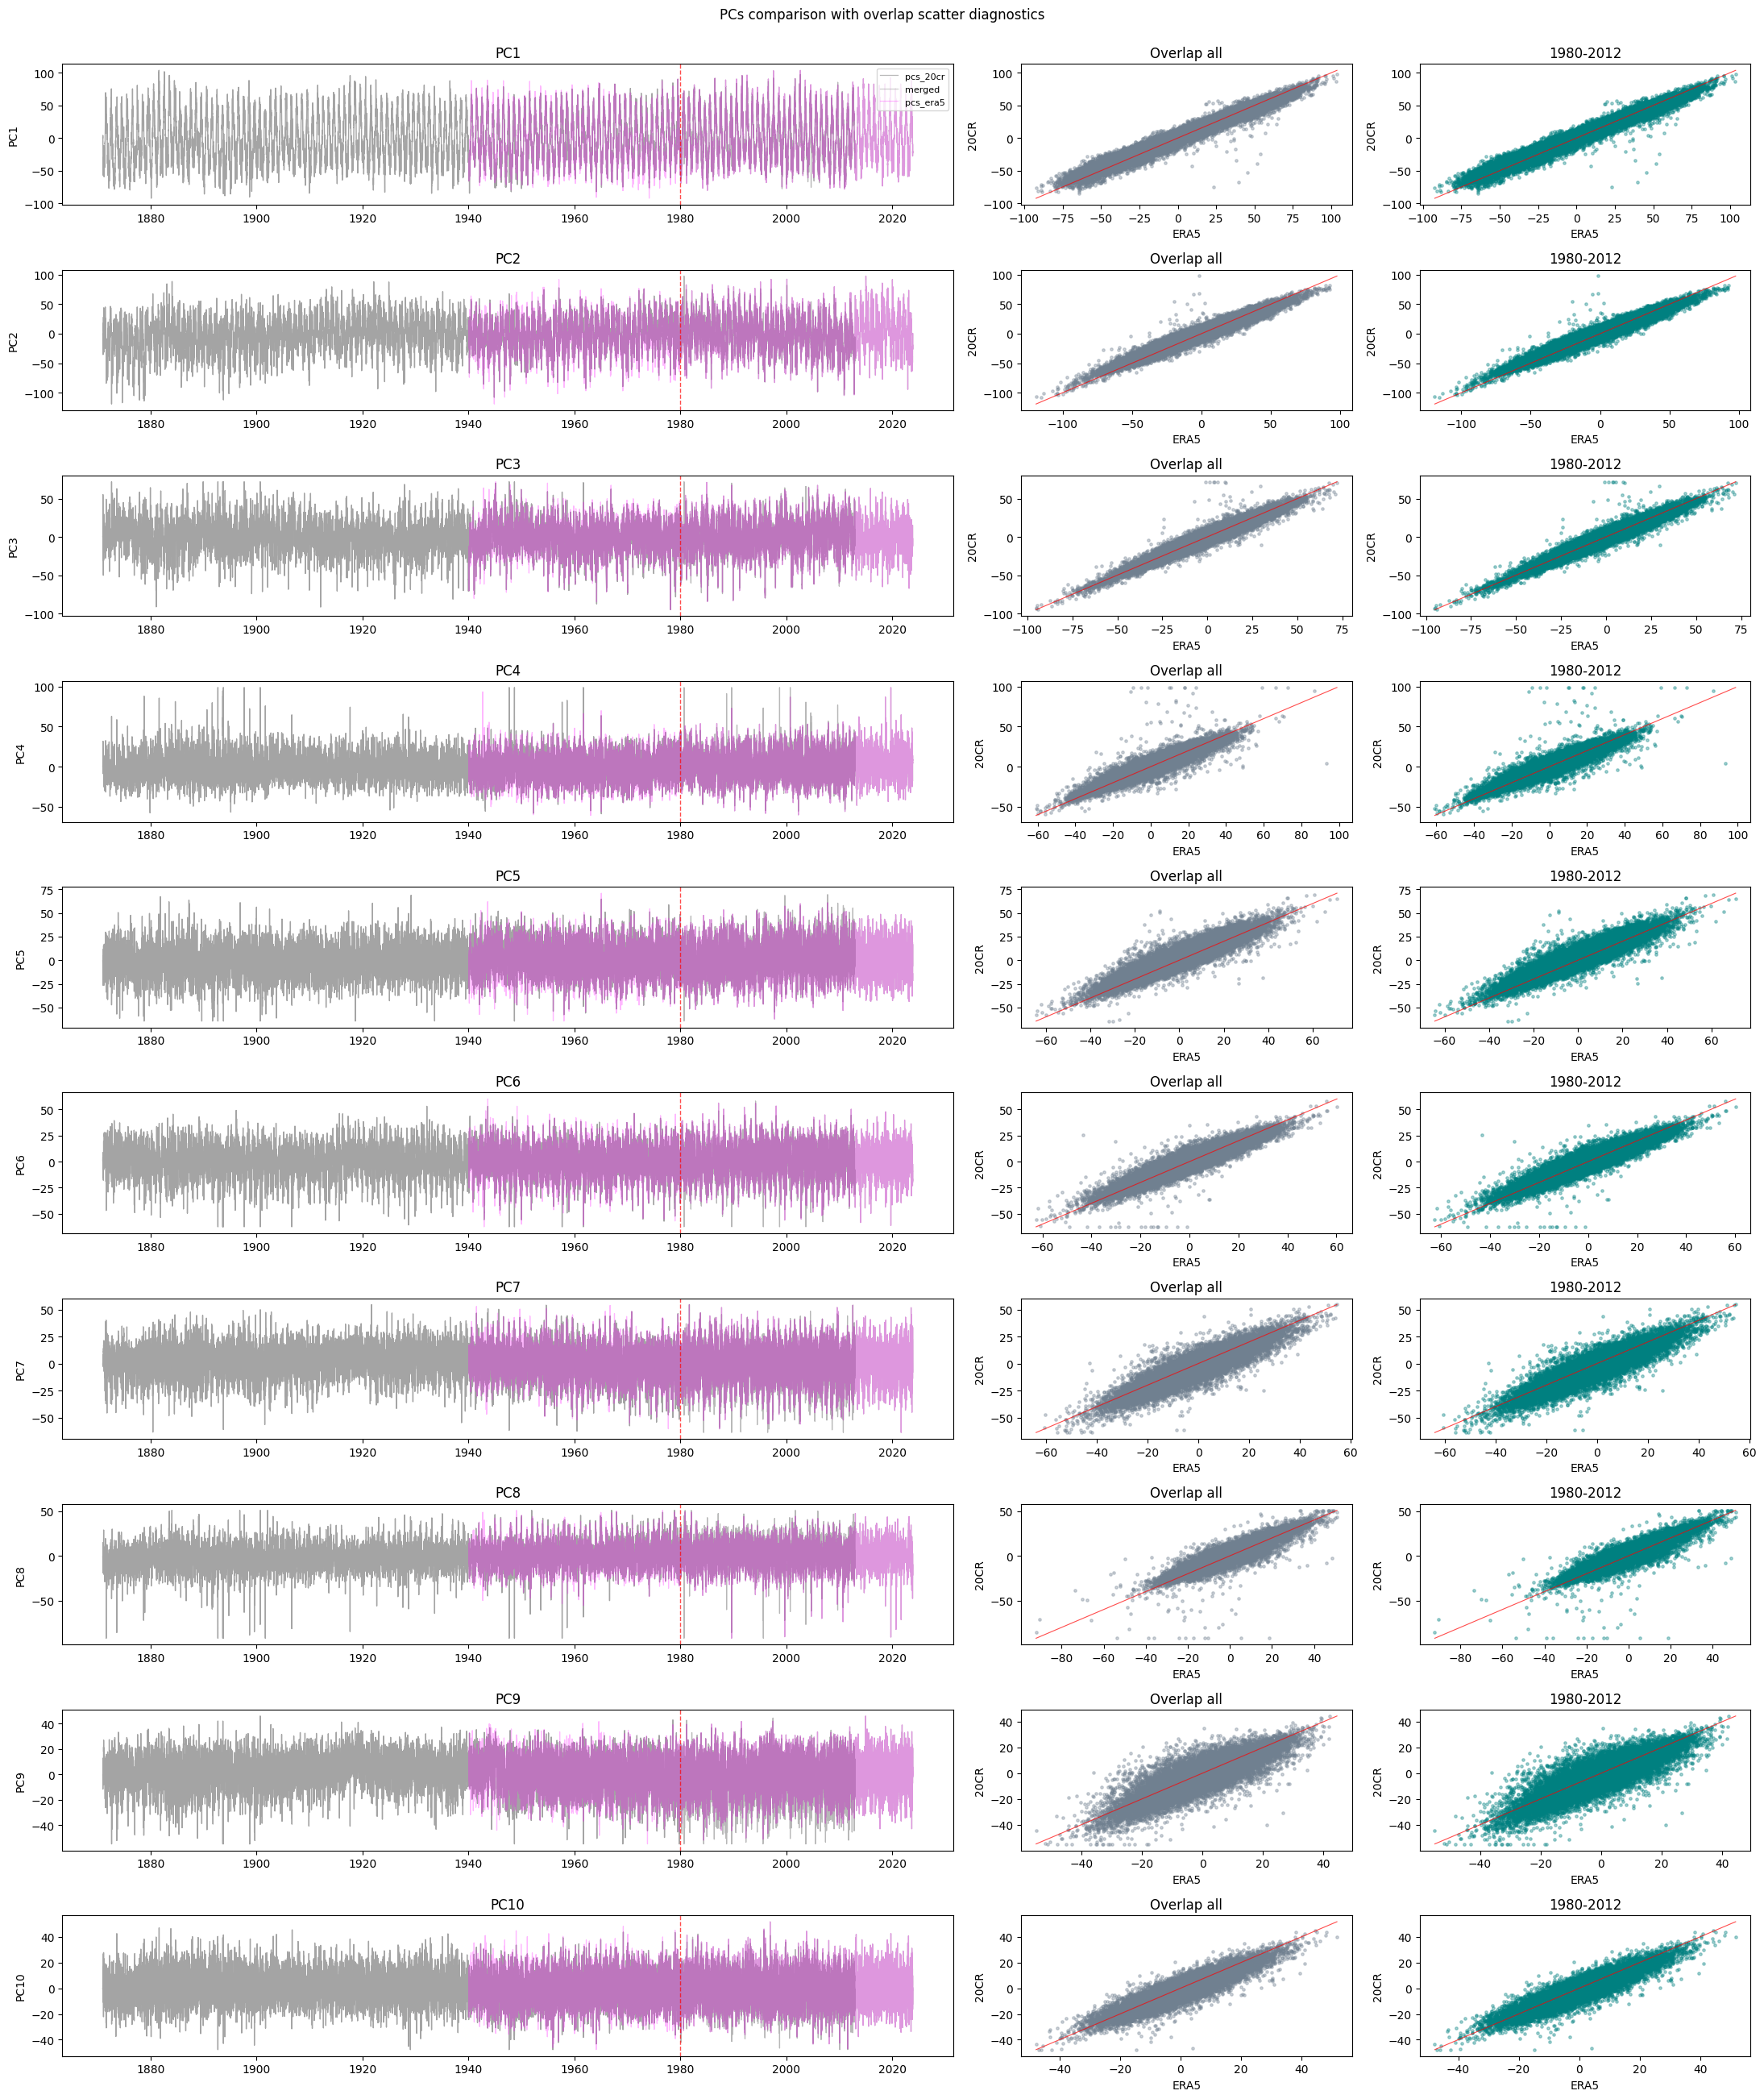

In [54]:
import matplotlib.pyplot as plt

# Join corrected 20CR PCs with ERA5 PCs using ERA5 from 1980 onward.
pcs_20cr = pcs_20cr_corrected.copy()
pcs_20cr.index = pd.to_datetime(pcs_20cr.index)

pcs_era5 = pca_mslp.pcs_df.copy()
pcs_era5.index = pd.to_datetime(pcs_era5.index)

join_date = pd.Timestamp("1980-01-01")
pc_cols_join = sorted(
    [c for c in pcs_20cr.columns.intersection(pcs_era5.columns) if c.startswith("PC")],
    key=lambda x: int(x[2:]),
)

# Keep 20CR only before join_date, and ERA5 from join_date onward.
pcs_20cr_hist = pcs_20cr.loc[pcs_20cr.index < join_date, pc_cols_join]
pcs_era5_tail = pcs_era5.loc[pcs_era5.index >= join_date, pc_cols_join]

pcs_20cr_era5 = pd.concat([pcs_20cr_hist, pcs_era5_tail], axis=0).sort_index()
pcs_20cr_era5 = pcs_20cr_era5.loc[~pcs_20cr_era5.index.duplicated(keep="last")]

out_csv = "/nfs/home/geocean/montanoj/New_data_Shoreshop/outputs/PCA/20cr_era5_pcs.csv"
pcs_20cr_era5.to_csv(out_csv)
print(f"Saved joined PCs to: {out_csv}")
print(f"Joined period: {pcs_20cr_era5.index.min().date()} -> {pcs_20cr_era5.index.max().date()}")

# Plot first 10 PCs with right-side scatter diagnostics.
plot_cols = [c for c in pc_cols_join if int(c[2:]) <= 10]
fig, axes = plt.subplots(
    len(plot_cols),
    3,
    figsize=(22, 2.6 * len(plot_cols)),
    gridspec_kw={"width_ratios": [3.5, 1.3, 1.3]},
)
if len(plot_cols) == 1:
    axes = [axes]

sub_period_start = pd.Timestamp("1940-01-01")
sub_period_end = pd.Timestamp("2012-12-31")

for i, col in enumerate(plot_cols):
    ax_ts, ax_sc_all, ax_sc_sub = axes[i]

    # Time series panel
    ax_ts.plot(pcs_20cr.index, pcs_20cr[col], color="black", lw=0.9, alpha=0.28, label="pcs_20cr")
    ax_ts.plot(pcs_20cr_era5.index, pcs_20cr_era5[col], color="gray", lw=1.0, alpha=0.35, label="merged")
    ax_ts.plot(pcs_era5.index, pcs_era5[col], color="fuchsia", lw=0.9, alpha=0.28, label="pcs_era5")
    ax_ts.axvline(join_date, color="red", ls="--", lw=1, alpha=0.7)
    ax_ts.set_title(col)
    ax_ts.set_ylabel(col)
    if i == 0:
        ax_ts.legend(loc="upper right", fontsize=8)

    # Full overlapping period scatter: x = ERA5, y = 20CR
    overlap_all = pd.concat(
        [pcs_era5[col].rename("era5"), pcs_20cr[col].rename("20cr")],
        axis=1,
        join="inner",
    ).dropna()
    ax_sc_all.scatter(overlap_all["era5"], overlap_all["20cr"], s=6, color="slategray", alpha=0.35)
    if len(overlap_all) > 0:
        vmin = min(overlap_all.min())
        vmax = max(overlap_all.max())
        ax_sc_all.plot([vmin, vmax], [vmin, vmax], color="red", lw=0.8, alpha=0.7)
    ax_sc_all.set_title("Overlap all")
    ax_sc_all.set_xlabel("ERA5")
    ax_sc_all.set_ylabel("20CR")

    # 1980-2012 overlap scatter: x = ERA5, y = 20CR
    overlap_sub = overlap_all.loc[(overlap_all.index >= sub_period_start) & (overlap_all.index <= sub_period_end)]
    ax_sc_sub.scatter(overlap_sub["era5"], overlap_sub["20cr"], s=6, color="teal", alpha=0.35)
    if len(overlap_sub) > 0:
        vmin = min(overlap_sub.min())
        vmax = max(overlap_sub.max())
        ax_sc_sub.plot([vmin, vmax], [vmin, vmax], color="red", lw=0.8, alpha=0.7)
    ax_sc_sub.set_title("1980-2012")
    ax_sc_sub.set_xlabel("ERA5")
    ax_sc_sub.set_ylabel("20CR")

fig.suptitle("PCs comparison with overlap scatter diagnostics", y=1.0)
plt.tight_layout()
plt.show()


## PCs Annomalies for AWT

In [55]:
# --- ESTELA DAILY input -> MONTHLY and ANNUAL anomalies only ---

import numpy as np
import pandas as pd
import xarray as xr

vars_pca = ["mslp", "mslp_gradient"]
da_estela_daily = mslp_20cr_std[vars_pca]

# 1) Detrend each gridpoint daily time series
def detrend_1d(y):
    y = np.asarray(y, dtype=float)
    t = np.arange(y.size, dtype=float)
    m = np.isfinite(y)

    out = np.full_like(y, np.nan, dtype=float)
    if m.sum() < 2:
        return out

    slope, intercept = np.polyfit(t[m], y[m], 1)
    out[m] = y[m] - (slope * t[m] + intercept)
    return out

da_estela_detr = xr.apply_ufunc(
    detrend_1d,
    da_estela_daily,
    input_core_dims=[["time"]],
    output_core_dims=[["time"]],
    vectorize=True,
    dask="parallelized",
    output_dtypes=[float],
)

# 2) Convert detrended DAILY data to true monthly means first
da_estela_monthly = da_estela_detr.resample(time="MS").mean(skipna=True)

# 3) Monthly anomalies from MONTHLY data (monthly timestamps)
clim_month = da_estela_monthly.groupby("time.month").mean("time", skipna=True)
anom_monthly = da_estela_monthly.groupby("time.month") - clim_month

# 4) Annual anomalies from MONTHLY detrended data
annual_mean = da_estela_monthly.resample(time="YS").mean(skipna=True)
annual_anom = annual_mean - annual_mean.mean("time", skipna=True)

# 5) Build xarray datasets
mslp_20cr_estela_monthly_anom = anom_monthly.astype(np.float32)

mslp_20cr_estela_annual_anom = annual_anom.astype(np.float32)


# 6) Independent PCA analysis on monthly anomaly field (new fit)
pca_20cr_estela_anom = PCA(n_components=0.95)
PCs_estela_anom = pca_20cr_estela_anom.fit_transform(
    data=mslp_20cr_estela_monthly_anom,
    vars_to_stack=vars_pca,
    coords_to_stack=["latitude", "longitude"],
    pca_dim_for_rows="time",
)

# 7) PC dataframe from this new PCA model
ncomp = PCs_estela_anom.sizes["n_component"]
df_pcs_estela_monthly_anom = pd.DataFrame(
    data=PCs_estela_anom["PCs"].values.astype(np.float32),
    columns=[f"PC{i+1}" for i in range(ncomp)],
    index=PCs_estela_anom["time"].values,
)

print("Created:")
print("- mslp_20cr_estela_monthly_anom (monthly timestamps, monthly anomalies)")
print("- mslp_20cr_estela_annual_anom (yearly timestamps, annual anomalies)")
print("- pca_20cr_estela_anom (new PCA model fitted on this dataset)")
print("- PCs_estela_monthly_anom")
print("- df_pcs_estela_monthly_anom")
display(df_pcs_estela_monthly_anom.head())
display(mslp_20cr_estela_annual_anom)


        -------------------------------------------------------------------
        | Initializing PCA reduction model with the following parameters:
        |    - n_components: 0.95
        |    - is_incremental: False
        | For more information, please refer to the documentation.
        -------------------------------------------------------------------
        


2026-07-07 12:08:44,648 - PCA - WARNING - Using 4488 out of 65160 available variablesIf this is originated by using few times, please check 'nan_threshold_to_drop' parameter in fit method
2026-07-07 12:08:44,770 - PCA - WARNING - Using 4488 out of 65160 available variablesIf this is originated by using few times, please check 'nan_threshold_to_drop' parameter in fit method


Created:
- mslp_20cr_estela_monthly_anom (monthly timestamps, monthly anomalies)
- mslp_20cr_estela_annual_anom (yearly timestamps, annual anomalies)
- pca_20cr_estela_anom (new PCA model fitted on this dataset)
- PCs_estela_monthly_anom
- df_pcs_estela_monthly_anom


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC61,PC62,PC63,PC64,PC65,PC66,PC67,PC68,PC69,PC70
1871-01-01,-34.369007,18.569742,50.624020,-15.329704,-8.356244,-0.207863,15.851562,-6.236999,-17.867558,-22.826740,...,2.087656,2.144317,2.121975,-2.054255,-1.819728,-1.291504,-1.242295,-1.483344,3.798155,-1.284170
1871-02-01,12.940373,-19.836128,-4.453803,3.875635,3.163012,-19.226566,16.387592,-25.619051,-3.086650,12.836173,...,2.798258,-4.132291,2.479503,0.479215,1.541755,1.431956,-0.551429,3.057139,-1.757430,3.373374
1871-03-01,18.675491,16.030134,4.768703,-12.985330,-22.595137,-19.132202,13.480294,0.389775,-10.865706,1.385435,...,0.291613,2.368585,-1.972891,0.249169,-0.324973,2.528286,0.799915,2.296895,-0.861909,-0.950223
1871-04-01,-14.951327,-24.609224,-4.494908,-30.124973,-11.652493,-8.957688,7.890385,-18.506643,-13.077908,4.503472,...,0.378658,-1.287739,-0.499377,3.055238,-2.332287,3.009527,-0.897738,1.670094,-0.047625,0.169208
1871-05-01,-35.113789,-17.933403,-30.744715,-16.803127,-17.034180,6.496783,9.607775,-14.915191,-14.442323,1.700480,...,3.553522,-2.475511,-2.743988,-0.411813,-1.805170,1.678448,-0.551489,2.529188,-2.177658,3.716045


<xarray.Dataset> Size: 74MB
Dimensions:        (time: 142, latitude: 181, longitude: 360)
Coordinates:
  * time           (time) datetime64[ns] 1kB 1871-01-01 ... 2012-01-01
  * latitude       (latitude) float32 724B 89.62 88.62 87.62 ... -89.38 -90.0
  * longitude      (longitude) float32 1kB 0.375 1.375 2.375 ... 358.4 359.4
Data variables:
    mslp           (time, latitude, longitude) float32 37MB nan nan ... nan nan
    mslp_gradient  (time, latitude, longitude) float32 37MB nan nan ... nan nan
Attributes:
    Conventions:    CF-1.2
    title:          4x Daily NOAA-CIRES 20th Century Reanalysis
    comments:       Data is from \nNOAA-CIRES 20th Century Reanalysis version...
    platform:       Model
    institution:    NOAA ESRL/PSD
    citation:       Compo,G.P. <http://www.esrl.noaa.gov/psd/people/gilbert.p...
    version:        2.0
    history:        created 2010/05 by Hoop (netCDF4)\nConverted to chunked, ...
    dataset_title:  NOAA-CIRES 20th Century Reanalysis (V2)
    References:     http://www.psl.noaa.gov/data/gridded/data.20thCentReanaly...

In [56]:
explained_variance = sum(pca_20cr_estela_anom.explained_variance_ratio[0:6])
explained_variance

np.float32(0.51700985)

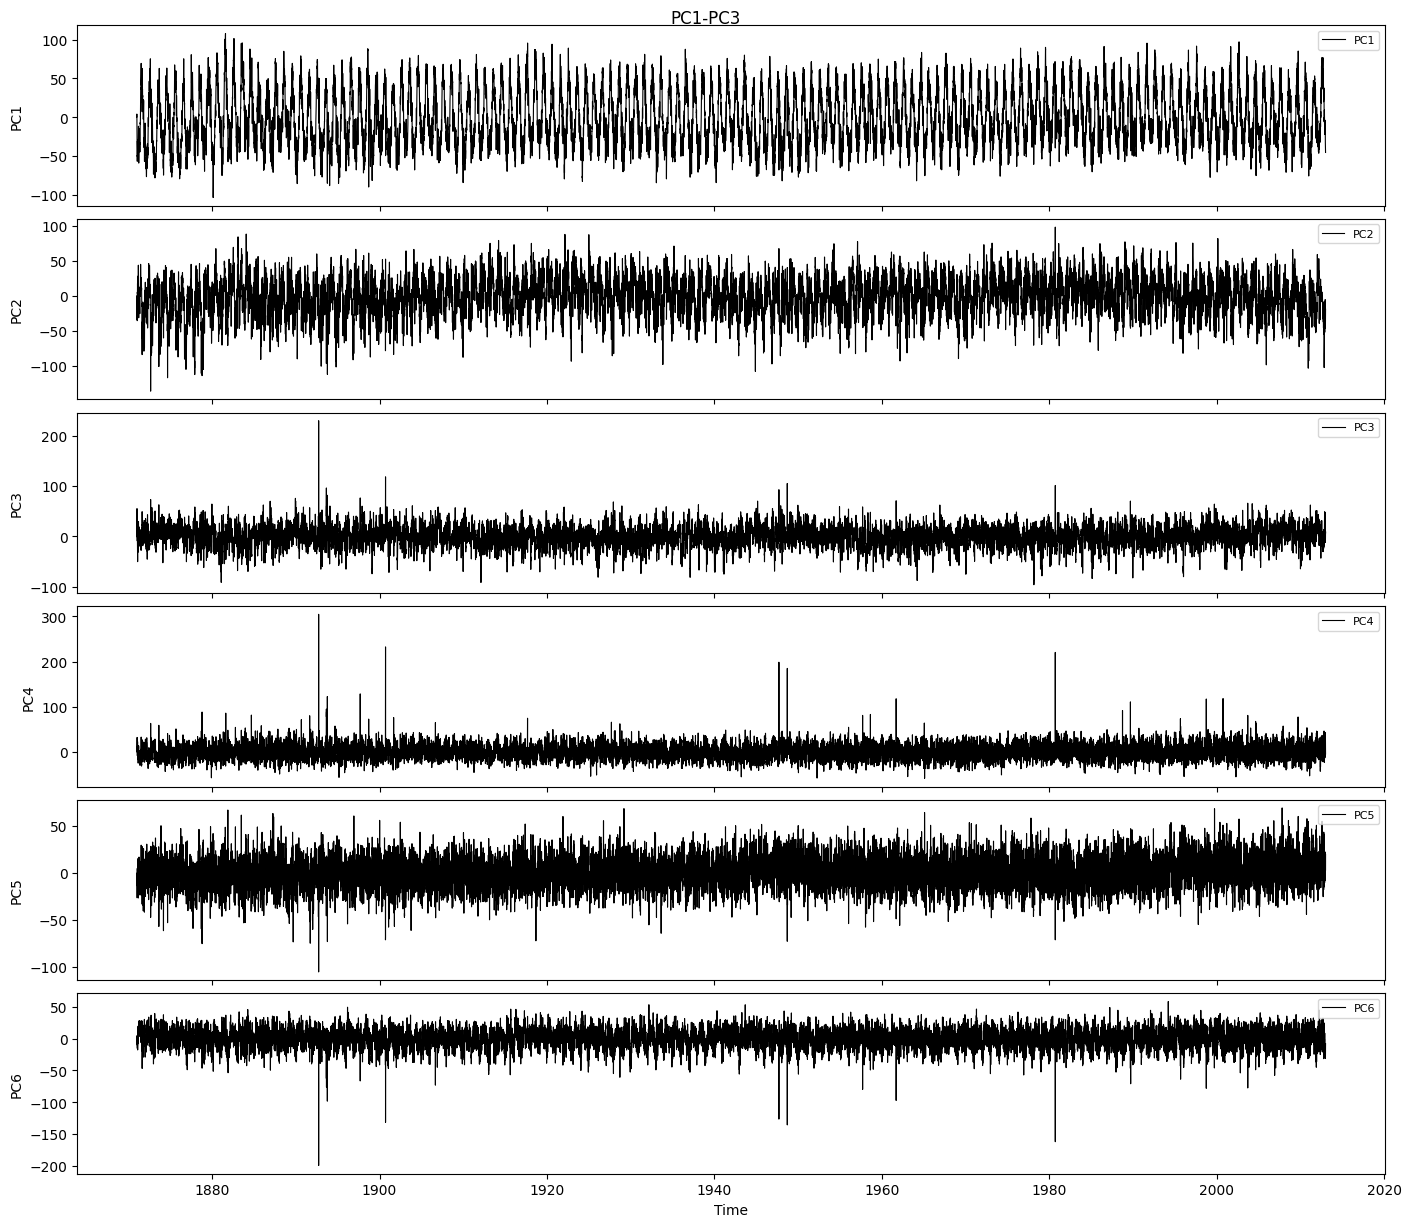

In [57]:
# Plot first 5 PCs and their linear trends (1 column x 5 rows)
import matplotlib.pyplot as plt
import numpy as np

# Use the first 5 PCs
pc_cols = list(df.columns[:6])
t = np.arange(len(df))

fig, axes = plt.subplots(nrows=6, ncols=1, figsize=(14, 12), sharex=True, constrained_layout=True)

for i, col in enumerate(pc_cols):
    y = df[col].values
    slope, intercept = np.polyfit(t, y, 1)
    # y_trend = slope * t + intercept

    axes[i].plot(df.index, y, color="black", lw=0.8, label=f"{col}")
    # axes[i].plot(df.index, y_trend, color="fuchsia", lw=1.6, label=f"trend (slope={slope:.2e})")
    # axes[i].axhline(0, color="gray", lw=0.5)
    axes[i].set_ylabel(col)
    axes[i].legend(loc="upper right", fontsize=8)

axes[-1].set_xlabel("Time")
fig.suptitle("PC1-PC3", y=1.01)
plt.show()

In [58]:
pca_20cr_estela_anom.save_model("/nfs/home/geocean/montanoj/New_data_Shoreshop/outputs/PCA/pca_20CR_anomalies.pkl")
pca_20cr_estela_anom.pcs_df.to_csv('/nfs/home/geocean/montanoj/New_data_Shoreshop/outputs/PCA/pcs_20cr_anomalies.csv')
pca_20cr_estela_anom.pcs.to_netcdf('/nfs/home/geocean/montanoj/New_data_Shoreshop/outputs/PCA/pcs_20cr_anomalies.nc')
pca_20cr_estela_anom.eofs.to_netcdf('/nfs/home/geocean/montanoj/New_data_Shoreshop/outputs/PCA/eofs_20cr_anomalies.nc')

2026-07-07 12:12:54,600 - PCA - WARNING - Attribute pcs is an xarray Dataset / Dataarray and will be pickled!


In [59]:
pca_20cr_estela_anom.pcs_df

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC61,PC62,PC63,PC64,PC65,PC66,PC67,PC68,PC69,PC70
1871-01-01,-34.369007,18.569742,50.624020,-15.329704,-8.356244,-0.207863,15.851562,-6.236999,-17.867558,-22.826740,...,2.087656,2.144317,2.121975,-2.054255,-1.819728,-1.291504,-1.242295,-1.483344,3.798155,-1.284170
1871-02-01,12.940373,-19.836128,-4.453803,3.875635,3.163012,-19.226566,16.387592,-25.619051,-3.086650,12.836173,...,2.798258,-4.132291,2.479503,0.479215,1.541755,1.431956,-0.551429,3.057139,-1.757430,3.373374
1871-03-01,18.675491,16.030134,4.768703,-12.985330,-22.595137,-19.132202,13.480294,0.389775,-10.865706,1.385435,...,0.291613,2.368585,-1.972891,0.249169,-0.324973,2.528286,0.799915,2.296895,-0.861909,-0.950223
1871-04-01,-14.951327,-24.609224,-4.494908,-30.124973,-11.652493,-8.957688,7.890385,-18.506643,-13.077908,4.503472,...,0.378658,-1.287739,-0.499377,3.055238,-2.332287,3.009527,-0.897738,1.670094,-0.047625,0.169208
1871-05-01,-35.113789,-17.933403,-30.744715,-16.803127,-17.034180,6.496783,9.607775,-14.915191,-14.442323,1.700480,...,3.553522,-2.475511,-2.743988,-0.411813,-1.805170,1.678448,-0.551489,2.529188,-2.177658,3.716045
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2012-08-01,-18.837208,-7.952098,12.020900,-27.710999,42.359245,-13.934451,22.052841,0.525265,-11.189994,-0.764114,...,-1.834274,-1.154787,2.497200,0.354881,-4.409223,-6.655984,-3.104486,3.481798,-5.589906,1.893054
2012-09-01,9.017052,-45.575031,62.303360,9.372000,-18.438583,-7.507361,1.740253,26.281332,31.823669,-4.844497,...,-3.444174,-10.362883,3.805245,5.062548,9.123235,-2.842385,-6.168521,4.907660,-3.085606,-1.318569
2012-10-01,-31.946093,-43.539223,62.670052,21.726974,17.559082,-8.736901,6.712842,20.722904,5.195395,-4.367216,...,5.810822,-3.334930,-4.130538,16.193058,1.864840,-2.767891,-2.688205,-8.886000,-3.264379,4.245280
2012-11-01,-55.633556,-11.428472,14.326904,-34.166283,28.099262,-1.091216,42.449333,11.926051,3.616887,-3.666316,...,-0.119794,-1.622310,-2.671938,1.876109,2.615389,-0.245314,-2.614325,4.616035,2.478812,-3.340801


### GCM Reprojection

In [46]:
models = ['ec_earth3_veg_lr'] # ['ec_earth3_veg_lr', 'miroc6']
scenarios = ['historical', 'ssp245', 'ssp585']

In [48]:
for model in models:
    for ssp in scenarios:
        
        print(f"Processing {model} - {ssp}")

        ds_gcm_mslp = xr.open_dataset(f'/nfs/home/geocean/montanoj/New_data_Shoreshop/outputs/cmip6_models/{model}/{ssp}/mslp_{model}_{ssp}_1deg_bias_corrected.nc')
        ds_gcm_mslp = ds_gcm_mslp.assign_coords(longitude=(ds_gcm_mslp.longitude % 360))
        ds_gcm_mslp = ds_gcm_mslp.sortby("longitude")

        ds_gcm_mslp_estela = get_dynamic_estela_predictor(data=ds_gcm_mslp, estela=estela).isel(time=slice(30,None))

        gcm_pca = pca_ob.transform(ds_gcm_mslp_estela[['mslp', 'mslp_gradient']])

        pcs_gcm = gcm_pca['PCs'].to_dataframe().unstack('n_component')
        pcs_gcm.columns = [f"PC{i+1}" for i in range(pcs_gcm.shape[1])]

        pcs_gcm.to_csv(f'/nfs/home/geocean/montanoj/New_data_Shoreshop/outputs/cmip6_models/{model}/{ssp}/mslp_{model}_{ssp}_pcs_95.csv')

        pc = 0

        x = era5_pcs.iloc[:, pc]
        y = pcs_gcm.iloc[:, pc]

        # Combine data to define common bins
        all_data = np.concatenate([x.values, y.values])

        # Create shared bins
        bins = np.histogram_bin_edges(all_data, bins=30)  # or 'auto'

        # Plot with same bins
        plt.hist(x, bins=bins, density=True, alpha=0.5, label="ERA5")
        plt.hist(y, bins=bins, density=True, alpha=0.5, label="GCM")

        plt.legend()
        plt.show()


Processing ec_earth3_veg_lr - historical


FileNotFoundError: [Errno 2] No such file or directory: '/lustre/geocean/WORK/users/montanoj/personal/NC_Emulator_BinWaves_Winds/outputs/cmip6_models/ec_earth3_veg_lr/historical/mslp_ec_earth3_veg_lr_historical_1deg_bias_corrected.nc'

In [ ]:
xr.open_dataset(f'/lustre/geocean/WORK/users/alonsoap/personal/mini_projects/stochastic_gcms_clean_nc/download/psl_day_MIROC6_ssp245_r1i1p1f1_gn_20250101-20341231.nc')

In [ ]:
xr.open_dataset('/nfs/home/geocean/cagigall/geocean/DATA/PROJECTIONS/MSLP/CMIP6/Projections/ssp5/psl_day_MIROC6_ssp585_r1i1p1f1_gn_20950101-21001231.nc')

#### Principal Component Analysis - SST

In [ ]:
data_sst = xr.open_dataset('inputs/data_daily_mslp_sst_mld_q_index.nc')
pca_sst = PCA(n_components=0.95)
pca_sst.fit_transform(data=data_sst, vars_to_stack=["sst"], coords_to_stack=["latitude", "longitude"], pca_dim_for_rows="time")
pca_sst.save_model("/nfs/home/geocean/montanoj/New_data_Shoreshop/outputs/PCA/pca_sst_model.pkl")
pca_sst.pcs_df.to_csv('/nfs/home/geocean/montanoj/New_data_Shoreshop/outputs/PCA/pcs_sst_df.csv')
pca_sst.pcs.to_netcdf('/nfs/home/geocean/montanoj/New_data_Shoreshop/outputs/PCA/pcs_sst_ds.nc')
pca_sst.eofs.to_netcdf('/nfs/home/geocean/montanoj/New_data_Shoreshop/outputs/PCA/eofs_sst.nc')

In [ ]:
pca_sst.plot_pcs(num_pcs=10)

In [ ]:
df = pca_sst.pcs_df

results = []

# numeric time variable
t = np.arange(len(df))

for col in df.columns:
    y = df[col].values
    X = sm.add_constant(t)
    model = sm.OLS(y, X).fit()

    results.append({
        "column": col,
        "slope": model.params[1],
        "p_value": model.pvalues[1],
        "r_squared": model.rsquared
    })

trend_results = pd.DataFrame(results)
trend_results

In [ ]:
pca_sst.plot_eofs(vars_to_plot=['sst'],num_eofs=23)